In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("/content/screener_2.csv")

In [3]:
df.sample(5)

,Ticker,Year,Borrowings,CFO,CWIP,Depreciation,EquityCapital,FCF,FixedAssets,Interest,Investments,NetProfit,OperatingProfit,OtherAssets,OtherLiabilities,PBT,Reserves,Sales,TotalAssets,TotalLiabilities
6529,PTCIL,2025.0,NaN,NaN,NaN,9.0,NaN,NaN,NaN,2.0,NaN,18.0,26.0,NaN,NaN,23.0,NaN,125.0,NaN,NaN
4007,INOXWIND,2026.0,1587.0,-598.0,247.0,52.0,1728.0,-1246.0,2825.0,65.0,550.0,106.0,200.0,8445.0,4099.0,144.0,4654.0,1244.0,12068.0,12068.0
323,ADANIPORTS,2024.0,NaN,NaN,NaN,1012.0,NaN,NaN,NaN,484.0,NaN,3107.0,4739.0,NaN,NaN,3593.0,NaN,7560.0,NaN,NaN
2221,DCMSHRIRAM,2024.0,NaN,NaN,NaN,101.0,NaN,NaN,NaN,38.0,NaN,63.0,181.0,NaN,NaN,96.0,NaN,2957.0,NaN,NaN
6302,PIIND,2024.0,191.0,2036.0,278.0,80.0,15.0,1417.0,3528.0,11.0,1336.0,370.0,442.0,5601.0,1822.0,411.0,8716.0,1741.0,10744.0,10744.0


In [4]:
df.shape

(8545, 20)

In [5]:
print("Number of companies:", df["Ticker"].nunique())

Number of companies: 469


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8545 entries, 0 to 8544
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Ticker            8545 non-null   object 
 1   Year              8535 non-null   float64
 2   Borrowings        4353 non-null   float64
 3   CFO               4878 non-null   float64
 4   CWIP              4906 non-null   float64
 5   Depreciation      7978 non-null   float64
 6   EquityCapital     4906 non-null   float64
 7   FCF               4878 non-null   float64
 8   FixedAssets       4906 non-null   float64
 9   Interest          7978 non-null   float64
 10  Investments       4906 non-null   float64
 11  NetProfit         7978 non-null   float64
 12  OperatingProfit   7978 non-null   float64
 13  OtherAssets       4906 non-null   float64
 14  OtherLiabilities  4906 non-null   float64
 15  PBT               7978 non-null   float64
 16  Reserves          4906 non-null   float64


In [7]:
# Duplicates Check
print("Rows:", len(df))

print(
    "Duplicate Ticker-Year pairs:",
    df[["Ticker","Year"]]
    .duplicated()
    .sum()
)

Rows: 8545
Duplicate Ticker-Year pairs: 3609


In [8]:
dups = df[
    df[["Ticker","Year"]]
    .duplicated(keep=False)
]

print(dups.shape)

dups.sort_values(
    ["Ticker","Year"]
).head(20)

(4835, 20)


,Ticker,Year,Borrowings,CFO,CWIP,Depreciation,EquityCapital,FCF,FixedAssets,Interest,Investments,NetProfit,OperatingProfit,OtherAssets,OtherLiabilities,PBT,Reserves,Sales,TotalAssets,TotalLiabilities
0,360ONE,2023.0,NaN,NaN,NaN,14.0,NaN,NaN,NaN,167.0,NaN,192.0,375.0,NaN,NaN,235.0,NaN,630.0,NaN,NaN
3,360ONE,2023.0,NaN,NaN,NaN,13.0,NaN,NaN,NaN,125.0,NaN,184.0,353.0,NaN,NaN,224.0,NaN,573.0,NaN,NaN
11,360ONE,2023.0,6784.0,-1323.0,39.0,12.0,36.0,-1395.0,880.0,108.0,3609.0,155.0,272.0,6663.0,1285.0,200.0,3086.0,482.0,11191.0,11191.0
15,360ONE,2023.0,NaN,NaN,NaN,14.0,NaN,NaN,NaN,146.0,NaN,186.0,313.0,NaN,NaN,227.0,NaN,550.0,NaN,NaN
1,360ONE,2024.0,NaN,NaN,NaN,17.0,NaN,NaN,NaN,222.0,NaN,276.0,444.0,NaN,NaN,359.0,NaN,780.0,NaN,NaN
4,360ONE,2024.0,NaN,NaN,NaN,16.0,NaN,NaN,NaN,214.0,NaN,244.0,577.0,NaN,NaN,345.0,NaN,849.0,NaN,NaN
12,360ONE,2024.0,9472.0,-470.0,64.0,17.0,36.0,-571.0,940.0,207.0,5948.0,243.0,286.0,8163.0,2193.0,323.0,3414.0,791.0,15114.0,15114.0
16,360ONE,2024.0,NaN,NaN,NaN,17.0,NaN,NaN,NaN,232.0,NaN,245.0,541.0,NaN,NaN,319.0,NaN,865.0,NaN,NaN
2,360ONE,2025.0,NaN,NaN,NaN,41.0,NaN,NaN,NaN,296.0,NaN,327.0,725.0,NaN,NaN,427.0,NaN,1181.0,NaN,NaN
5,360ONE,2025.0,NaN,NaN,NaN,32.0,NaN,NaN,NaN,229.0,NaN,285.0,566.0,NaN,NaN,374.0,NaN,911.0,NaN,NaN


In [9]:
# Duplicates Removing

def first_non_null(series):
    s = series.dropna()
    return s.iloc[0] if len(s) else np.nan

df = (
    df.groupby(
        ["Ticker","Year"],
        as_index=False
    )
    .agg(first_non_null)
)


print(df.shape)  # shape without duplicates

(4926, 20)


In [10]:
print(
    df[["Ticker","Year"]]
    .duplicated()
    .sum()
)

0


In [11]:
df[df["Ticker"] == "BATAINDIA"]

,Ticker,Year,Borrowings,CFO,CWIP,Depreciation,EquityCapital,FCF,FixedAssets,Interest,Investments,NetProfit,OperatingProfit,OtherAssets,OtherLiabilities,PBT,Reserves,Sales,TotalAssets,TotalLiabilities
623,BATAINDIA,2015.0,0.0,119.0,48.0,79.00,64.0,-15.0,309.0,18.00,0.0,231.00,351.00,1280.0,616.0,329.00,957.0,2694.00,1637.0,1637.0
624,BATAINDIA,2016.0,0.0,204.0,19.0,79.00,64.0,165.0,304.0,16.00,0.0,217.00,294.00,1410.0,512.0,297.00,1157.0,2423.00,1733.0,1733.0
625,BATAINDIA,2017.0,0.0,257.0,30.0,65.00,64.0,209.0,268.0,15.00,0.0,159.00,296.00,1625.0,599.0,234.00,1260.0,2474.00,1923.0,1923.0
626,BATAINDIA,2018.0,0.0,160.0,12.0,60.00,64.0,85.0,296.0,15.00,0.0,221.00,364.00,1833.0,667.0,337.00,1410.0,2634.00,2141.0,2141.0
627,BATAINDIA,2019.0,0.0,345.0,17.0,64.00,64.0,263.0,317.0,14.00,0.0,329.00,490.00,2140.0,732.0,478.00,1678.0,2931.00,2474.0,2474.0
628,BATAINDIA,2020.0,1249.0,582.0,20.0,296.00,64.0,496.0,1369.0,129.00,0.0,329.00,846.00,2343.0,589.0,487.00,1830.0,3056.00,3732.0,3732.0
629,BATAINDIA,2021.0,1032.0,461.0,34.0,265.00,64.0,425.0,1120.0,108.00,0.0,-89.00,169.00,2179.0,542.0,-117.00,1694.0,1708.00,3332.0,3332.0
630,BATAINDIA,2022.0,1094.0,212.0,5.0,242.00,64.0,164.0,1226.0,99.00,0.0,103.00,427.00,2294.0,616.0,140.00,1750.0,2388.00,3525.0,3525.0
631,BATAINDIA,2023.0,1246.0,629.0,4.0,85.99,64.0,539.0,1392.0,29.46,0.0,57.98,182.44,1876.0,587.0,78.04,1374.0,903.47,3272.0,3272.0
632,BATAINDIA,2024.0,1357.0,453.0,4.0,90.18,64.0,355.0,1509.0,31.11,0.0,58.70,199.51,1837.0,466.0,77.30,1463.0,918.79,3350.0,3350.0


In [12]:
df[(df['Ticker'] == 'IKS') & (df['Year'] == 2025)]

,Ticker,Year,Borrowings,CFO,CWIP,Depreciation,EquityCapital,FCF,FixedAssets,Interest,Investments,NetProfit,OperatingProfit,OtherAssets,OtherLiabilities,PBT,Reserves,Sales,TotalAssets,TotalLiabilities
2214,IKS,2025.0,856.0,318.0,13.0,32.0,17.0,276.0,1790.0,23.0,114.0,183.0,279.0,1003.0,274.0,229.0,1773.0,815.0,2919.0,2919.0


df : without duplicate rows

In [13]:
df.dropna(subset=['Year'], inplace=True)

In [14]:
# Convert Everything in Numeric

numeric_cols = [
    col for col in df.columns
    if col not in ["Ticker", "Year"]
]

for col in numeric_cols:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


print(df.dtypes)

Ticker               object
Year                float64
Borrowings          float64
CFO                 float64
CWIP                float64
Depreciation        float64
EquityCapital       float64
FCF                 float64
FixedAssets         float64
Interest            float64
Investments         float64
NetProfit           float64
OperatingProfit     float64
OtherAssets         float64
OtherLiabilities    float64
PBT                 float64
Reserves            float64
Sales               float64
TotalAssets         float64
TotalLiabilities    float64
dtype: object


In [15]:
# Missing Value Check

missing = pd.DataFrame({ "MissingCount": df.isna().sum(), "MissingPct": round(df.isna().mean()*100,2) })

print( missing.sort_values( "MissingPct", ascending=False ) )

                  MissingCount  MissingPct
Borrowings                 577       11.71
NetProfit                  553       11.23
Interest                   553       11.23
Depreciation               553       11.23
PBT                        553       11.23
Sales                      553       11.23
OperatingProfit            553       11.23
CFO                         49        0.99
FCF                         49        0.99
FixedAssets                 24        0.49
Investments                 24        0.49
EquityCapital               24        0.49
OtherLiabilities            24        0.49
Reserves                    24        0.49
CWIP                        24        0.49
OtherAssets                 24        0.49
TotalAssets                 24        0.49
TotalLiabilities            24        0.49
Ticker                       0        0.00
Year                         0        0.00


In [16]:
df['Year'] = df['Year'].astype(int)
display(df.head())

,Ticker,Year,Borrowings,CFO,CWIP,Depreciation,EquityCapital,FCF,FixedAssets,Interest,Investments,NetProfit,OperatingProfit,OtherAssets,OtherLiabilities,PBT,Reserves,Sales,TotalAssets,TotalLiabilities
0,360ONE,2018,6966.0,-2772.0,22.0,14.0,16.0,-2809.0,31.0,559.0,1111.0,380.0,1053.0,8403.0,737.0,490.0,1847.0,1705.0,9567.0,9567.0
1,360ONE,2019,6103.0,1852.0,173.0,22.0,17.0,1643.0,337.0,431.0,3053.0,375.0,990.0,6200.0,749.0,538.0,2894.0,1578.0,9763.0,9763.0
2,360ONE,2020,8838.0,1628.0,1.0,41.0,17.0,1536.0,608.0,502.0,6512.0,201.0,823.0,5899.0,1191.0,286.0,2974.0,1521.0,13021.0,13021.0
3,360ONE,2021,5077.0,463.0,2.0,43.0,18.0,437.0,837.0,414.0,2513.0,369.0,939.0,5386.0,834.0,485.0,2810.0,1654.0,8739.0,8739.0
4,360ONE,2022,5808.0,929.0,0.0,42.0,18.0,912.0,816.0,370.0,4072.0,578.0,1157.0,5846.0,1903.0,751.0,3006.0,2072.0,10734.0,10734.0


In [17]:
# Sorting year

df = (
    df.sort_values(
        ["Ticker", "Year"]
    )
)

df.head()

,Ticker,Year,Borrowings,CFO,CWIP,Depreciation,EquityCapital,FCF,FixedAssets,Interest,Investments,NetProfit,OperatingProfit,OtherAssets,OtherLiabilities,PBT,Reserves,Sales,TotalAssets,TotalLiabilities
0,360ONE,2018,6966.0,-2772.0,22.0,14.0,16.0,-2809.0,31.0,559.0,1111.0,380.0,1053.0,8403.0,737.0,490.0,1847.0,1705.0,9567.0,9567.0
1,360ONE,2019,6103.0,1852.0,173.0,22.0,17.0,1643.0,337.0,431.0,3053.0,375.0,990.0,6200.0,749.0,538.0,2894.0,1578.0,9763.0,9763.0
2,360ONE,2020,8838.0,1628.0,1.0,41.0,17.0,1536.0,608.0,502.0,6512.0,201.0,823.0,5899.0,1191.0,286.0,2974.0,1521.0,13021.0,13021.0
3,360ONE,2021,5077.0,463.0,2.0,43.0,18.0,437.0,837.0,414.0,2513.0,369.0,939.0,5386.0,834.0,485.0,2810.0,1654.0,8739.0,8739.0
4,360ONE,2022,5808.0,929.0,0.0,42.0,18.0,912.0,816.0,370.0,4072.0,578.0,1157.0,5846.0,1903.0,751.0,3006.0,2072.0,10734.0,10734.0


In [18]:
print("Number of companies:", df["Ticker"].nunique())

Number of companies: 469


In [19]:
# Company Coverage : data available yearwise

company_years = (
    df.groupby("Ticker")
      .size()
)

print(company_years.describe())

print(
    company_years.value_counts()
                 .sort_index()
)

count    469.000000
mean      10.503198
std        2.559232
min        1.000000
25%        9.000000
50%       12.000000
75%       12.000000
max       13.000000
dtype: float64
1       1
2       3
3       5
4      15
5      12
6       9
7      28
8      26
9      23
10     20
11     10
12    312
13      5
Name: count, dtype: int64


In [20]:
# Yearwise Missingness of most missing variables

# which variables are missing most ?

profitability_vars = [
    "Sales",
    "OperatingProfit",
    "NetProfit",
    "Interest",
    "PBT",
    "Depreciation"
]

summary = (
    df.groupby("Ticker")
      [profitability_vars]
      .count()
      .min(axis=1)
)

print(
    summary.value_counts()
           .sort_index()
)

0      53
1       1
2       3
3       5
4      12
5       9
6       8
7      26
8      23
9      22
10     17
11      9
12    276
13      5
Name: count, dtype: int64


In [21]:
profitability_vars = [
    "Sales",
    "OperatingProfit",
    "NetProfit",
    "Interest",
    "PBT",
    "Depreciation"
]

counts = (
    df.groupby("Ticker")[profitability_vars]
      .count()
)

for col in profitability_vars:
    print("\n", col)
    print(counts[col].value_counts().sort_index())

print("\nCompanies with all six variables missing:")

all_zero = (counts == 0).all(axis=1)
print(all_zero.value_counts())


 Sales
Sales
0      53
1       1
2       3
3       5
4      12
5       9
6       8
7      26
8      23
9      22
10     17
11      9
12    276
13      5
Name: count, dtype: int64

 OperatingProfit
OperatingProfit
0      53
1       1
2       3
3       5
4      12
5       9
6       8
7      26
8      23
9      22
10     17
11      9
12    276
13      5
Name: count, dtype: int64

 NetProfit
NetProfit
0      53
1       1
2       3
3       5
4      12
5       9
6       8
7      26
8      23
9      22
10     17
11      9
12    276
13      5
Name: count, dtype: int64

 Interest
Interest
0      53
1       1
2       3
3       5
4      12
5       9
6       8
7      26
8      23
9      22
10     17
11      9
12    276
13      5
Name: count, dtype: int64

 PBT
PBT
0      53
1       1
2       3
3       5
4      12
5       9
6       8
7      26
8      23
9      22
10     17
11      9
12    276
13      5
Name: count, dtype: int64

 Depreciation
Depreciation
0      53
1       1
2       3
3       5
4 

In [22]:
problem_companies = counts[
    (counts == 0).all(axis=1)
]

print(problem_companies.index.tolist())

['AADHARHFC', 'AAVAS', 'ABCAPITAL', 'AIIL', 'APTUS', 'AUBANK', 'AXISBANK', 'BAJFINANCE', 'BANKBARODA', 'BANKINDIA', 'CANBK', 'CENTRALBK', 'CGCL', 'CHOLAFIN', 'CHOLAHLDNG', 'CREDITACC', 'FEDERALBNK', 'FIVESTAR', 'HDBFS', 'HDFCBANK', 'HUDCO', 'ICICIBANK', 'IDBI', 'IDFCFIRSTB', 'IFCI', 'IIFL', 'INDIANB', 'INDUSINDBK', 'IOB', 'IREDA', 'J&KBANK', 'KOTAKBANK', 'LICHSGFIN', 'LTF', 'M&MFIN', 'MAHABANK', 'MANAPPURAM', 'MUTHOOTFIN', 'PFC', 'PNB', 'PNBHOUSING', 'POONAWALLA', 'RBLBANK', 'RECLTD', 'SAMMAANCAP', 'SBFC', 'SBIN', 'SHRIRAMFIN', 'SUNDARMFIN', 'TATACAP', 'UCOBANK', 'UNIONBANK', 'YESBANK']


In [23]:
# Good Companies that means which have profitability var data for at least 1 year and Is there any improvement in missing values?

good_companies = summary[summary > 0].index

df_model = df[
    df["Ticker"].isin(good_companies)
].copy()

print(df_model.shape)
print(df_model["Ticker"].nunique())

(4373, 20)
416


In [24]:
company_years = (
    df_model.groupby("Ticker")
            .size()
)

print(company_years.describe())

print(
    company_years.value_counts()
                 .sort_index()
)

count    416.000000
mean      10.512019
std        2.550663
min        1.000000
25%        9.000000
50%       12.000000
75%       12.000000
max       13.000000
dtype: float64
1       1
2       3
3       5
4      12
5       9
6       8
7      26
8      23
9      22
10     17
11      9
12    276
13      5
Name: count, dtype: int64


`df_model` : Keeping only those companies that have complete profitability data (Sales, OperatingProfit, NetProfit, Interest, PBT, Depreciation) for at least 1 year.

In [25]:
df_model = df[
    df["Ticker"].isin(good_companies)
].copy()

print(df_model.shape)
print(df_model["Ticker"].nunique())

missing_model = pd.DataFrame({ "MissingCount": df_model.isna().sum(), "MissingPct": round(df_model.isna().mean()*100,2) })
print( missing_model.sort_values( "MissingPct", ascending=False ) )


(4373, 20)
416
                  MissingCount  MissingPct
CFO                         48        1.10
FCF                         48        1.10
CWIP                        24        0.55
Borrowings                  24        0.55
TotalLiabilities            24        0.55
Reserves                    24        0.55
EquityCapital               24        0.55
FixedAssets                 24        0.55
Investments                 24        0.55
TotalAssets                 24        0.55
OtherLiabilities            24        0.55
OtherAssets                 24        0.55
Ticker                       0        0.00
Year                         0        0.00
Depreciation                 0        0.00
Interest                     0        0.00
NetProfit                    0        0.00
OperatingProfit              0        0.00
PBT                          0        0.00
Sales                        0        0.00


In [26]:
# Missing data handling

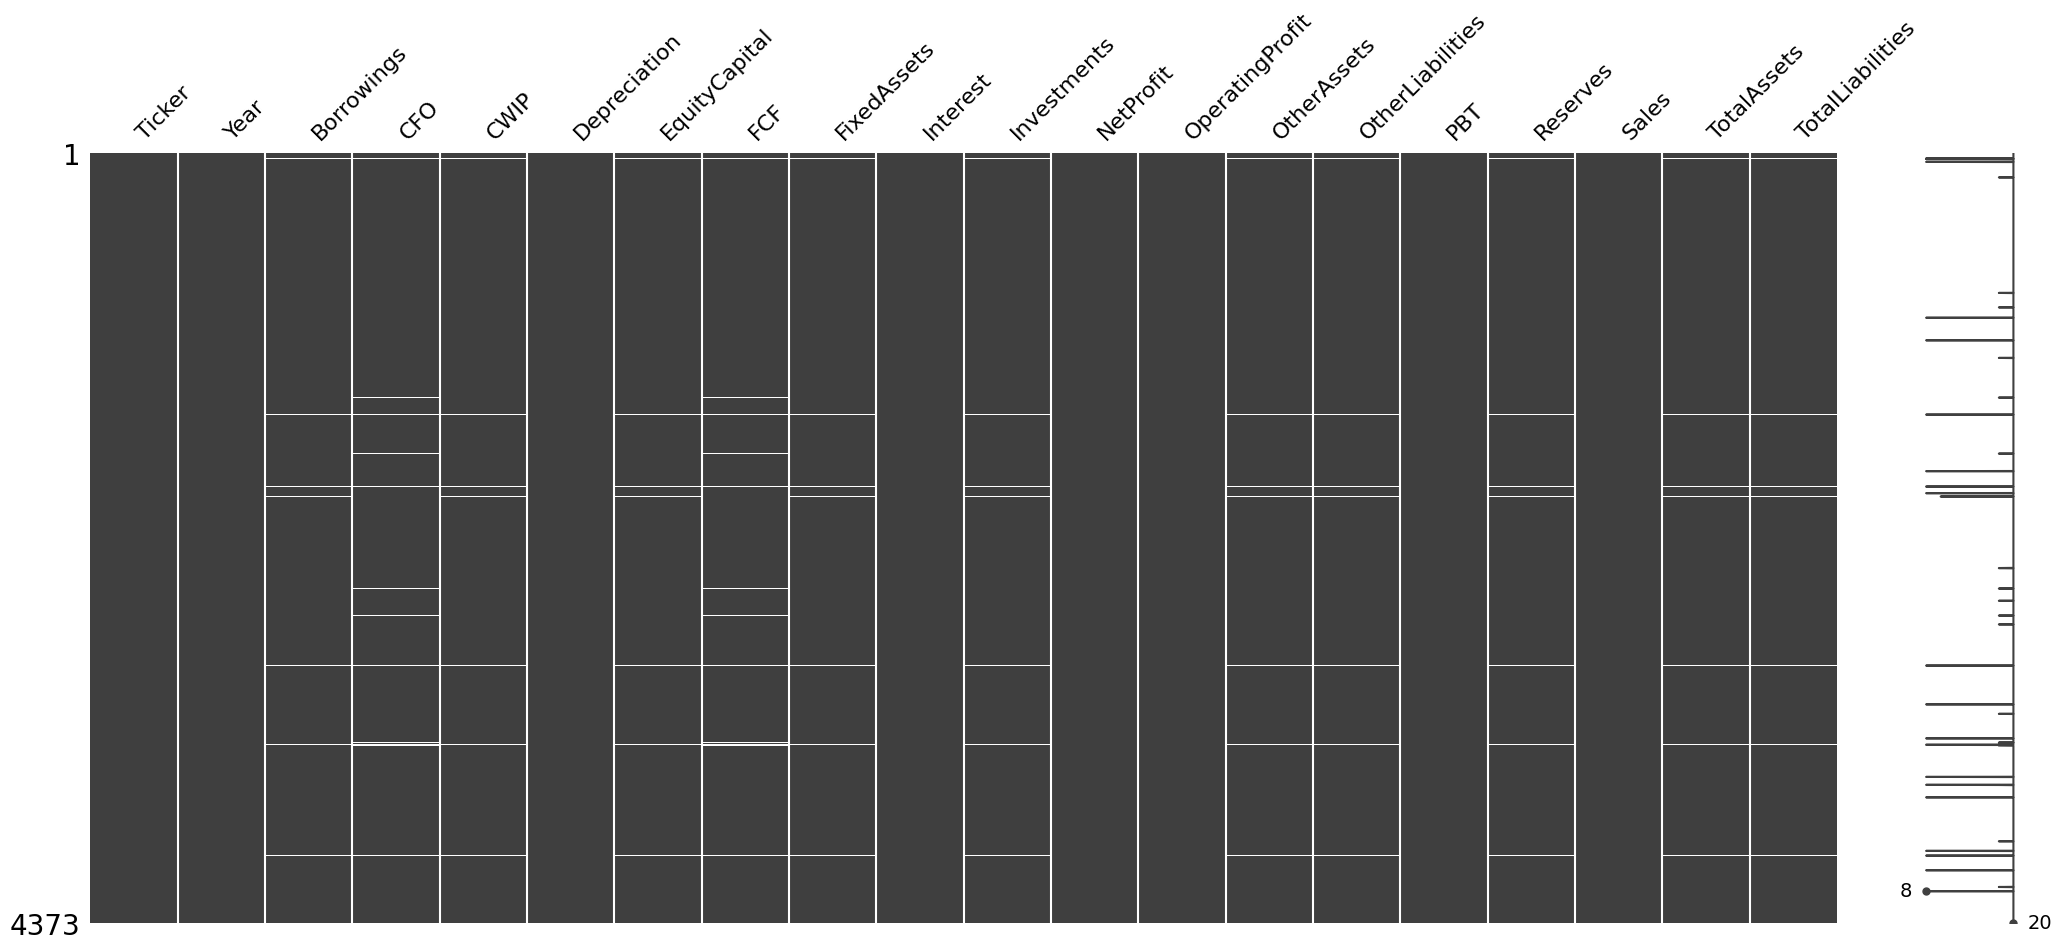

In [27]:
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(df_model)

plt.show()

The observed pattern suggests that missingness arises from unavailable balance sheet or cash flow statements for specific company-years rather than widespread or systematic data loss.

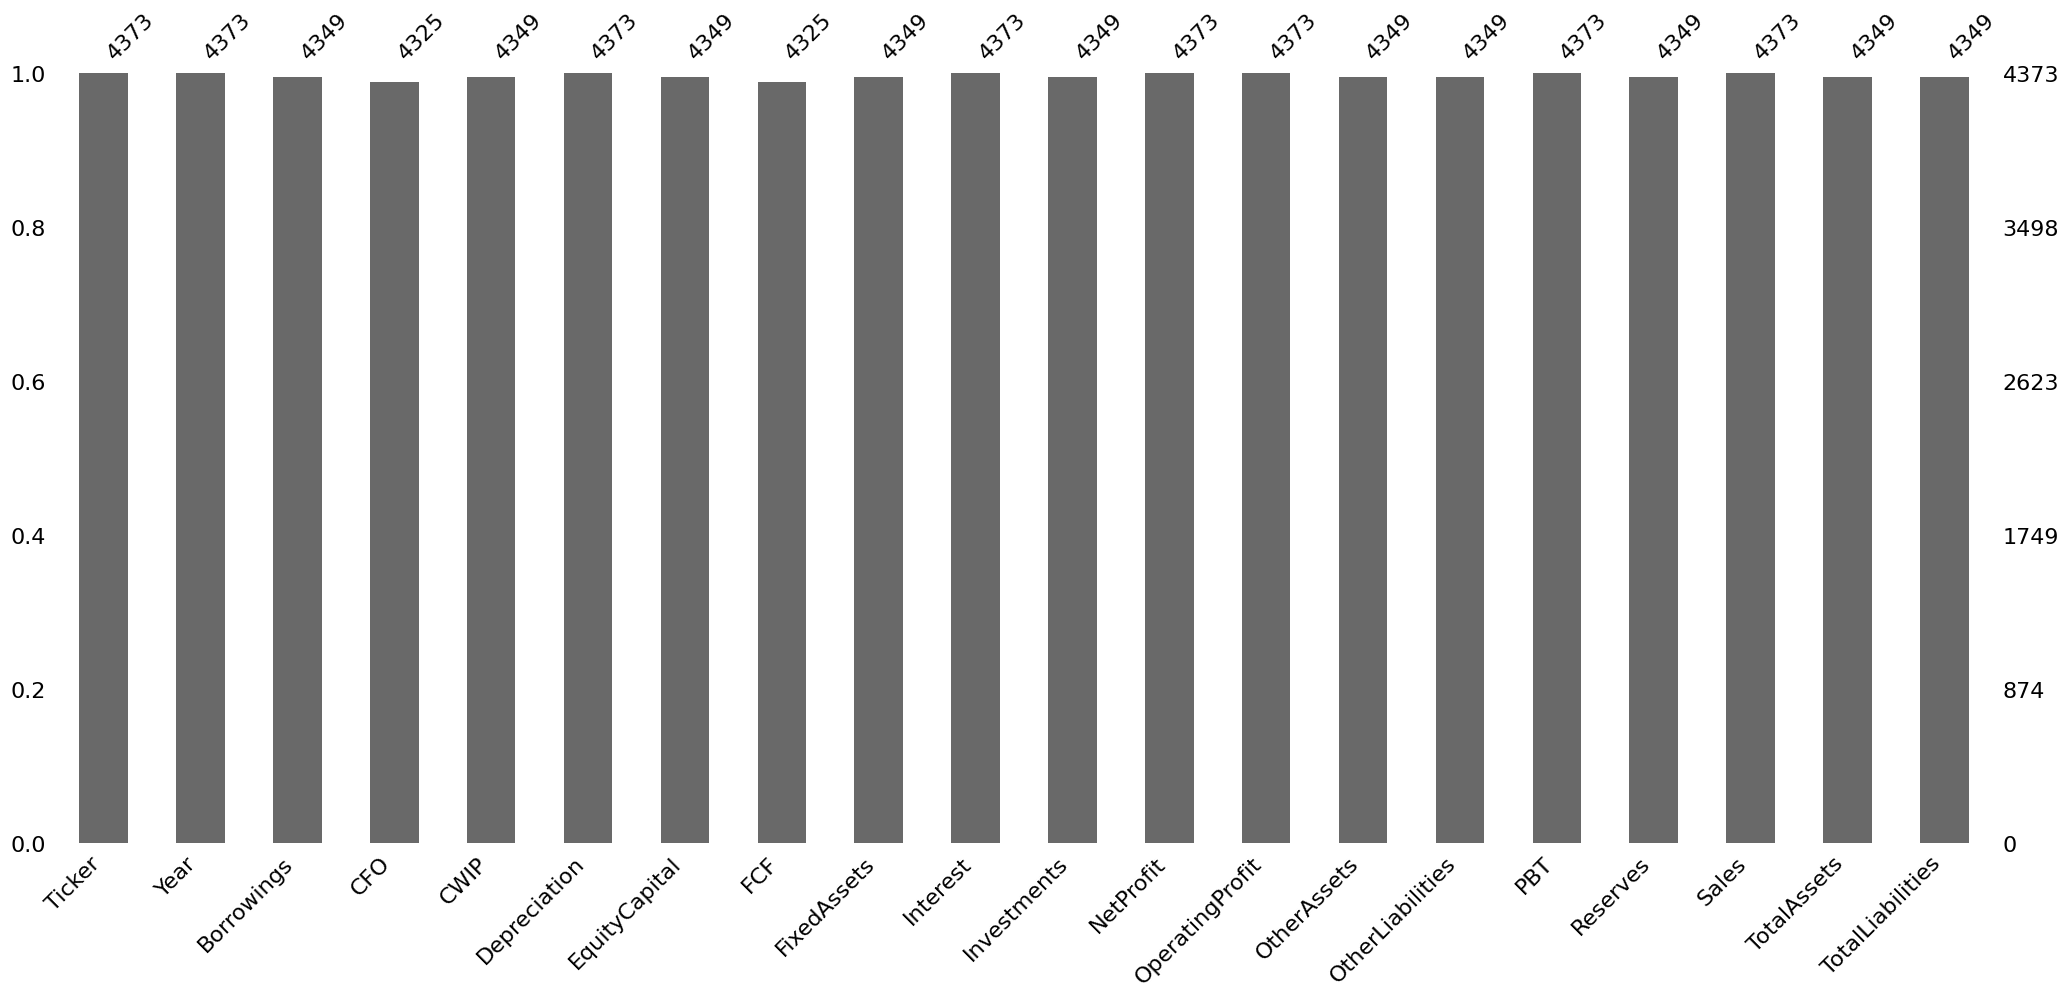

In [28]:
msno.bar(df_model)

plt.show()

In [29]:
missing_rows = df_model[
    df_model.isna().any(axis=1)
]

print(missing_rows.shape)

missing_rows.sort_values(
    ["Ticker","Year"]
)

(49, 20)


,Ticker,Year,Borrowings,CFO,CWIP,Depreciation,EquityCapital,FCF,FixedAssets,Interest,Investments,NetProfit,OperatingProfit,OtherAssets,OtherLiabilities,PBT,Reserves,Sales,TotalAssets,TotalLiabilities
45,ABB,2019,NaN,NaN,NaN,22.0,NaN,NaN,NaN,10.0,NaN,130.0,124.0,NaN,NaN,173.0,NaN,1726.0,NaN,NaN
46,ABB,2022,NaN,NaN,NaN,26.0,NaN,NaN,NaN,3.0,NaN,146.0,200.0,NaN,NaN,196.0,NaN,2098.0,NaN,NaN
49,ABB,2026,NaN,NaN,NaN,42.0,NaN,NaN,NaN,4.0,NaN,1784.0,408.0,NaN,NaN,1904.0,NaN,3184.0,NaN,NaN
77,ABLBL,2024,NaN,NaN,NaN,176.0,NaN,NaN,NaN,96.0,NaN,60.0,333.0,NaN,NaN,83.0,NaN,2138.0,NaN,NaN
165,ADANIGREEN,2016,4132.0,NaN,1962.0,6.0,160.00,NaN,2781.0,23.0,7.0,-9.0,13.0,819.0,1286.0,-9.0,-9.0,28.0,5569.0,5569.0
899,CARTRADE,2016,31.0,NaN,0.0,1.0,3.00,NaN,792.0,0.0,165.0,-146.0,-162.0,65.0,39.0,-146.0,948.0,33.0,1021.0,1021.0
1005,CHALET,2015,2072.0,NaN,49.0,62.0,152.00,NaN,2295.0,161.0,13.0,-126.0,64.0,885.0,538.0,-141.0,480.0,441.0,3242.0,3242.0
1088,CIEINDIA,2026,NaN,NaN,NaN,94.0,NaN,NaN,NaN,9.0,NaN,249.0,402.0,NaN,NaN,329.0,NaN,2612.0,NaN,NaN
1224,CRISIL,2026,NaN,NaN,NaN,39.0,NaN,NaN,NaN,7.0,NaN,233.0,319.0,NaN,NaN,308.0,NaN,1058.0,NaN,NaN
1324,DEVYANI,2016,348.0,NaN,38.0,85.0,106.00,NaN,491.0,43.0,0.0,-130.0,-1.0,192.0,196.0,-129.0,70.0,1012.0,720.0,720.0


In [30]:
print(
    missing_rows["Ticker"]
    .value_counts()
)

Ticker
RAILTEL       6
ABB           3
HAL           2
LATENTVIEW    2
TEGA          2
KALYANKJIL    2
ETERNAL       2
SIEMENS       2
ICICIAMC      2
ADANIGREEN    1
ABLBL         1
GABRIEL       1
DEVYANI       1
CIEINDIA      1
HEXT          1
IKS           1
CRISIL        1
CARTRADE      1
CHALET        1
MANKIND       1
LODHA         1
IGIL          1
MAZDOCK       1
PGEL          1
PTCIL         1
PATANJALI     1
NESTLEIND     1
SCHAEFFLER    1
RADICO        1
SPLPETRO      1
TIMKEN        1
TMCV          1
TTML          1
UTIAMC        1
VBL           1
Name: count, dtype: int64


Strategy : Forward/Median Fill

In [31]:
# Create a copy for imputation

df_imputed = df_model.copy()

In [32]:
df_imputed = (
    df_imputed
    .sort_values(["Ticker", "Year"])
    .reset_index(drop=True)
)

In [33]:
df_imputed.head(15)

,Ticker,Year,Borrowings,CFO,CWIP,Depreciation,EquityCapital,FCF,FixedAssets,Interest,Investments,NetProfit,OperatingProfit,OtherAssets,OtherLiabilities,PBT,Reserves,Sales,TotalAssets,TotalLiabilities
0,360ONE,2018,6966.0,-2772.0,22.0,14.0,16.0,-2809.0,31.0,559.0,1111.0,380.0,1053.0,8403.0,737.0,490.0,1847.0,1705.0,9567.0,9567.0
1,360ONE,2019,6103.0,1852.0,173.0,22.0,17.0,1643.0,337.0,431.0,3053.0,375.0,990.0,6200.0,749.0,538.0,2894.0,1578.0,9763.0,9763.0
2,360ONE,2020,8838.0,1628.0,1.0,41.0,17.0,1536.0,608.0,502.0,6512.0,201.0,823.0,5899.0,1191.0,286.0,2974.0,1521.0,13021.0,13021.0
3,360ONE,2021,5077.0,463.0,2.0,43.0,18.0,437.0,837.0,414.0,2513.0,369.0,939.0,5386.0,834.0,485.0,2810.0,1654.0,8739.0,8739.0
4,360ONE,2022,5808.0,929.0,0.0,42.0,18.0,912.0,816.0,370.0,4072.0,578.0,1157.0,5846.0,1903.0,751.0,3006.0,2072.0,10734.0,10734.0
5,360ONE,2023,6784.0,-1323.0,39.0,14.0,36.0,-1395.0,880.0,167.0,3609.0,192.0,375.0,6663.0,1285.0,235.0,3086.0,630.0,11191.0,11191.0
6,360ONE,2024,9472.0,-470.0,64.0,17.0,36.0,-571.0,940.0,222.0,5948.0,276.0,444.0,8163.0,2193.0,359.0,3414.0,780.0,15114.0,15114.0
7,360ONE,2025,11160.0,-2411.0,88.0,41.0,39.0,-2458.0,1281.0,296.0,7608.0,327.0,725.0,10791.0,1543.0,427.0,7026.0,1181.0,19768.0,19768.0
8,360ONE,2026,15931.0,-2921.0,0.0,43.0,41.0,-3017.0,3969.0,312.0,8842.0,289.0,663.0,14389.0,1434.0,363.0,9795.0,1115.0,27201.0,27201.0
9,3MINDIA,2018,10.0,36.0,6.0,44.0,11.0,19.0,303.0,2.0,0.0,333.0,499.0,2001.0,1234.0,508.0,1055.0,2710.0,2311.0,2311.0


In [34]:
missing_before = pd.DataFrame({
    "MissingCount": df_imputed.isna().sum(),
    "MissingPct": (df_imputed.isna().mean()*100).round(2)
})

print(
    missing_before.sort_values(
        "MissingPct",
        ascending=False
    )
)

                  MissingCount  MissingPct
CFO                         48        1.10
FCF                         48        1.10
CWIP                        24        0.55
Borrowings                  24        0.55
TotalLiabilities            24        0.55
Reserves                    24        0.55
EquityCapital               24        0.55
FixedAssets                 24        0.55
Investments                 24        0.55
TotalAssets                 24        0.55
OtherLiabilities            24        0.55
OtherAssets                 24        0.55
Ticker                       0        0.00
Year                         0        0.00
Depreciation                 0        0.00
Interest                     0        0.00
NetProfit                    0        0.00
OperatingProfit              0        0.00
PBT                          0        0.00
Sales                        0        0.00


In [35]:
# Forward Filling within each company

df_imputed = (
    df_imputed
    .groupby("Ticker", group_keys=False)
    .apply(lambda x: x.ffill())
)

/tmp/ipykernel_1079/4076908431.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.ffill())


In [36]:
missing_after_ffill = pd.DataFrame({
    "MissingCount": df_imputed.isna().sum(),
    "MissingPct": (df_imputed.isna().mean()*100).round(2)
})

print(
    missing_after_ffill.sort_values(
        "MissingPct",
        ascending=False
    )
)

                  MissingCount  MissingPct
CFO                         33        0.75
FCF                         33        0.75
CWIP                        10        0.23
Borrowings                  10        0.23
TotalLiabilities            10        0.23
Reserves                    10        0.23
EquityCapital               10        0.23
FixedAssets                 10        0.23
Investments                 10        0.23
TotalAssets                 10        0.23
OtherLiabilities            10        0.23
OtherAssets                 10        0.23
Ticker                       0        0.00
Year                         0        0.00
Depreciation                 0        0.00
Interest                     0        0.00
NetProfit                    0        0.00
OperatingProfit              0        0.00
PBT                          0        0.00
Sales                        0        0.00


In [37]:
# Fill remaining missing values with overall median, avoiding bfill

cols_to_fill = [
    "CFO","FCF","CWIP","Borrowings","TotalLiabilities","Reserves","EquityCapital","TotalAssets","FixedAssets","Investments","OtherLiabilities","OtherAssets"
]

for col in cols_to_fill:
    df_imputed[col] = df_imputed[col].fillna(
        df_imputed[col].median()
    )

In [38]:
missing_after_ffill = pd.DataFrame({
    "MissingCount": df_imputed.isna().sum(),
    "MissingPct": (df_imputed.isna().mean()*100).round(2)
})

print(
    missing_after_ffill.sort_values(
        "MissingPct",
        ascending=False
    )
)

                  MissingCount  MissingPct
Ticker                       0         0.0
Year                         0         0.0
Borrowings                   0         0.0
CFO                          0         0.0
CWIP                         0         0.0
Depreciation                 0         0.0
EquityCapital                0         0.0
FCF                          0         0.0
FixedAssets                  0         0.0
Interest                     0         0.0
Investments                  0         0.0
NetProfit                    0         0.0
OperatingProfit              0         0.0
OtherAssets                  0         0.0
OtherLiabilities             0         0.0
PBT                          0         0.0
Reserves                     0         0.0
Sales                        0         0.0
TotalAssets                  0         0.0
TotalLiabilities             0         0.0


In [39]:
remaining_missing = df_imputed[
    df_imputed.isna().any(axis=1)
]

remaining_missing

,Ticker,Year,Borrowings,CFO,CWIP,Depreciation,EquityCapital,FCF,FixedAssets,Interest,Investments,NetProfit,OperatingProfit,OtherAssets,OtherLiabilities,PBT,Reserves,Sales,TotalAssets,TotalLiabilities


In [40]:
# Remove rows that still contain any missing values

df_final = df_imputed.dropna().copy()

In [41]:
print(df_final.shape)

print(df_final["Ticker"].nunique())

print(df_final.isna().sum())

(4373, 20)
416
Ticker              0
Year                0
Borrowings          0
CFO                 0
CWIP                0
Depreciation        0
EquityCapital       0
FCF                 0
FixedAssets         0
Interest            0
Investments         0
NetProfit           0
OperatingProfit     0
OtherAssets         0
OtherLiabilities    0
PBT                 0
Reserves            0
Sales               0
TotalAssets         0
TotalLiabilities    0
dtype: int64


Some Rechecking

In [42]:
duplicates = df_final.duplicated(subset=["Ticker", "Year"]).sum()

print("Duplicate company-year rows:", duplicates)

Duplicate company-year rows: 0


In [43]:
company_years = (
    df_final.groupby("Ticker")
            .size()
)

print(company_years.describe())

print(company_years.value_counts().sort_index())

count    416.000000
mean      10.512019
std        2.550663
min        1.000000
25%        9.000000
50%       12.000000
75%       12.000000
max       13.000000
dtype: float64
1       1
2       3
3       5
4      12
5       9
6       8
7      26
8      23
9      22
10     17
11      9
12    276
13      5
Name: count, dtype: int64


In [44]:
df_final.shape

(4373, 20)

Label Creation

`Rule 1`: Equity ≤ 0

`Rule 2`: *DebtAssets ≥ Sector 90th Percentile* AND *Negative CFO for 2 consecutive years*

`Rule 3`: Interest Coverage < 1 for 2 consecutive years

In [45]:
# Total Equity

df_final["Equity"] = (
    df_final["EquityCapital"] +
    df_final["Reserves"]
)

df_final["Equity"].describe()

,Equity
count,4373.000000
mean,12379.950386
std,39158.175464
min,-104167.000000
25%,1485.000000
50%,3447.000000
75%,9221.000000
max,904030.000000


In [46]:
(df_final["Equity"] <= 0).sum()

np.int64(70)

In [47]:
df_final.loc[
    df_final["Equity"] <= 0,
    ["Ticker","Year","Equity"]
].head(20)

,Ticker,Year,Equity
869,CGPOWER,2020,-1956.0
870,CGPOWER,2021,-84.0
1166,DEVYANI,2019,-70.0
1167,DEVYANI,2020,-189.0
1409,FACT,2015,-852.0
1410,FACT,2016,-1310.0
1411,FACT,2017,-1512.0
1412,FACT,2018,-1639.0
1413,FACT,2019,-1472.0
1414,FACT,2020,-491.0


In [48]:
# Rule 1 = Equity <= 0

rule1_companies = df_final.loc[
    df_final["Equity"] <= 0,
    "Ticker"
].nunique()

print(rule1_companies)

24


In [49]:
df_final.loc[
    df_final["Equity"] <= 0,
    "Ticker"
].value_counts()

,count
Ticker,
GMRAIRPORT,8
SUZLON,8
FACT,7
IDEA,6
INDIAMART,4
SIGNATURE,3
PATANJALI,3
HONASA,3
SWIGGY,3


In [50]:
tickers = (
    df_final["Ticker"]
    .drop_duplicates()
    .sort_values()
    .tolist()
)

print("Number of companies:", len(tickers))
print(tickers)

Number of companies: 416
['360ONE', '3MINDIA', 'AARTIIND', 'ABB', 'ABDL', 'ABFRL', 'ABLBL', 'ABREL', 'ABSLAMC', 'ACC', 'ACE', 'ACMESOLAR', 'ACUTAAS', 'ADANIENSOL', 'ADANIENT', 'ADANIGREEN', 'ADANIPORTS', 'ADANIPOWER', 'AEGISLOG', 'AEGISVOPAK', 'AFCONS', 'AFFLE', 'AIAENG', 'AJANTPHARM', 'ALKEM', 'AMBER', 'AMBUJACEM', 'ANANDRATHI', 'ANANTRAJ', 'ANGELONE', 'ANTHEM', 'ANURAS', 'APARINDS', 'APLAPOLLO', 'APOLLOHOSP', 'APOLLOTYRE', 'ARE&M', 'ASAHIINDIA', 'ASHOKLEY', 'ASIANPAINT', 'ASTERDM', 'ASTRAL', 'ATGL', 'ATUL', 'AUROPHARMA', 'AWL', 'BAJAJ-AUTO', 'BAJAJFINSV', 'BAJAJHLDNG', 'BALKRISIND', 'BALRAMCHIN', 'BATAINDIA', 'BAYERCROP', 'BBTC', 'BEL', 'BELRISE', 'BEML', 'BERGEPAINT', 'BHARATFORG', 'BHARTIARTL', 'BHEL', 'BIKAJI', 'BIOCON', 'BLS', 'BLUEDART', 'BLUEJET', 'BLUESTARCO', 'BOSCHLTD', 'BPCL', 'BRIGADE', 'BRITANNIA', 'BSE', 'BSOFT', 'CAMS', 'CAPLIPOINT', 'CARBORUNIV', 'CARTRADE', 'CCL', 'CDSL', 'CEATLTD', 'CEMPRO', 'CESC', 'CGPOWER', 'CHALET', 'CHAMBLFERT', 'CHENNPETRO', 'CHOICEIN', 'CIEIND

In [51]:
# Rule 2 :

# Rule 2.(a) = Debt/Asset > Sector Threshold
# Rule 2.(b) = CFO < 0 for 2 consecutive years

In [52]:
# Using sector specific information for rule 2

sector = pd.read_csv("industry_mapping.csv")

df_final = df_final.merge(
    sector[["Ticker", "Sector"]],
    on="Ticker",
    how="left"
)

In [53]:
df_final.sample(5)

,Ticker,Year,Borrowings,CFO,CWIP,Depreciation,EquityCapital,FCF,FixedAssets,Interest,...,OperatingProfit,OtherAssets,OtherLiabilities,PBT,Reserves,Sales,TotalAssets,TotalLiabilities,Equity,Sector
1288,EIHOTEL,2026,252.0,993.0,218.0,38.0,125.0,302.0,3881.0,6.0,...,334.0,1801.0,1041.0,368.0,5137.0,895.0,6556.0,6556.0,5262.0,Consumer Cyclical
3264,POLYCAB,2022,118.0,512.0,375.0,202.0,149.0,-8.0,1675.0,35.0,...,1264.0,4588.0,1750.0,1188.0,5394.0,12204.0,7412.0,7412.0,5543.0,Industrials
2884,NAVINFLUOR,2025,1466.0,571.0,355.0,36.0,10.0,4.0,2736.0,28.0,...,308.0,1259.0,738.0,238.0,2616.0,892.0,4830.0,4830.0,2626.0,Basic Materials
3449,RPOWER,2015,33219.0,1399.0,15531.0,524.0,2805.0,-761.0,33634.0,1074.0,...,2587.0,12001.0,8175.0,1286.0,17827.0,6903.0,62026.0,62026.0,20632.0,Utilities
1766,HDFCLIFE,2023,950.0,6883.0,31.0,0.0,2149.0,6797.0,997.0,0.0,...,264.0,8844.0,234126.0,367.0,10844.0,26927.0,248069.0,248069.0,12993.0,Financial Services


In [54]:
print(df_final["Sector"].isna().sum())
print(df_final["Sector"].nunique())
df_final["Sector"].value_counts()

0
11


,count
Sector,
Industrials,923
Basic Materials,665
Consumer Cyclical,641
Healthcare,505
Technology,406
Financial Services,305
Consumer Defensive,284
Utilities,215
Energy,161


In [55]:
# Creating Debt/Asset Ratio

df_final["DebtAssets"] = (
    df_final["Borrowings"] /
    df_final["TotalAssets"]
)

df_final["DebtAssets"].describe()

,DebtAssets
count,4370.000000
mean,0.212830
std,0.227161
min,0.000000
25%,0.038169
50%,0.165144
75%,0.335164
max,6.448845


In [56]:
# Sector wise threshold

sector_threshold = (
    df_final
    .groupby(["Sector", "Year"])["DebtAssets"]   #  We must group by both ["Sector", "Year"] so companies are only compared to their peers in that specific year.
    .quantile(0.90)                              # To prevent Time Series Data Leakage
)

print(sector_threshold)

# Assigning threshold

df_final["SectorThreshold"] = df_final.set_index(["Sector", "Year"]).index.map(sector_threshold)


Sector           Year
Basic Materials  2005    0.141844
                 2006    0.296381
                 2007    0.270321
                 2008    0.230263
                 2009    0.203166
                           ...   
Utilities        2022    0.660917
                 2023    0.646835
                 2024    0.634570
                 2025    0.588534
                 2026    0.630896
Name: DebtAssets, Length: 175, dtype: float64


In [57]:
df_final.sample(5)

,Ticker,Year,Borrowings,CFO,CWIP,Depreciation,EquityCapital,FCF,FixedAssets,Interest,...,OtherLiabilities,PBT,Reserves,Sales,TotalAssets,TotalLiabilities,Equity,Sector,DebtAssets,SectorThreshold
1399,EXIDEIND,2017,187.0,937.0,149.0,226.0,85.0,497.0,2259.0,153.0,...,12546.0,1097.0,4947.0,11179.0,17765.0,17765.0,5032.0,Consumer Cyclical,0.010526,0.456638
2869,NAVA,2022,3587.0,608.0,17.0,295.0,29.0,545.0,5546.0,338.0,...,2161.0,896.0,4924.0,3348.0,10701.0,10701.0,4953.0,Industrials,0.335202,0.485232
455,AUROPHARMA,2020,5826.0,4381.0,1986.0,967.0,59.0,2969.0,9396.0,305.0,...,6113.0,3743.0,16766.0,23099.0,28765.0,28765.0,16825.0,Healthcare,0.202538,0.403939
4230,VOLTAS,2025,892.0,-225.0,82.0,21.0,33.0,-416.0,973.0,31.0,...,5702.0,116.0,6480.0,3071.0,13108.0,13108.0,6513.0,Consumer Cyclical,0.068050,0.458516
3557,SHREECEM,2017,1293.0,2202.0,710.0,1215.0,35.0,922.0,2599.0,129.0,...,2175.0,1531.0,7663.0,8594.0,11166.0,11166.0,7698.0,Basic Materials,0.115798,0.526330


In [58]:
# Hgh Debt

df_final["HighDebt"] = (
    df_final["DebtAssets"] >=
    df_final["SectorThreshold"]
).astype(int)

In [59]:
print(df_final["HighDebt"].value_counts())

print(
    round(
        df_final["HighDebt"]
        .value_counts(normalize=True)*100,
        2
    )
)

HighDebt
0    3838
1     535
Name: count, dtype: int64
HighDebt
0    87.77
1    12.23
Name: proportion, dtype: float64


In [60]:
df_final.sample(5)

,Ticker,Year,Borrowings,CFO,CWIP,Depreciation,EquityCapital,FCF,FixedAssets,Interest,...,PBT,Reserves,Sales,TotalAssets,TotalLiabilities,Equity,Sector,DebtAssets,SectorThreshold,HighDebt
3676,SUMICHEM,2022,38.0,222.0,35.0,45.0,499.0,109.0,390.0,8.0,...,576.0,1428.0,3061.0,3010.0,3010.0,1927.0,Basic Materials,0.012625,0.346347,0
4345,ZFCVINDIA,2023,0.0,298.0,77.0,26.0,9.0,171.0,587.0,1.0,...,135.0,2400.0,899.0,3022.0,3022.0,2409.0,Consumer Cyclical,0.000000,0.546728,0
1948,IKS,2024,1311.0,210.0,3.0,28.0,17.0,177.0,1833.0,21.0,...,160.0,1141.0,657.0,2880.0,2880.0,1158.0,Healthcare,0.455208,0.353188,1
3144,PCBL,2016,1022.0,422.0,80.0,62.0,34.0,388.0,1416.0,72.0,...,47.0,1010.0,1894.0,2590.0,2590.0,1044.0,Basic Materials,0.394595,0.555636,0
2674,MAXHEALTH,2025,3010.0,1459.0,901.0,111.0,972.0,500.0,11502.0,60.0,...,365.0,8409.0,2068.0,15186.0,15186.0,9381.0,Healthcare,0.198209,0.325168,0


In [61]:
# CFO Rule

df_final = df_final.sort_values(["Ticker", "Year"])

df_final["NegativeCFO"] = (
    df_final["CFO"] < 0
).astype(int)

df_final["NegativeCFO"].value_counts()

,count
NegativeCFO,
0,3903
1,470


In [62]:
# We will observe CFO < 0 for 2 consecutive years to avoid false negatives

df_final["NegativeCFO2Y"] = (
    df_final.groupby("Ticker")["NegativeCFO"]
            .transform(
                lambda x: x.eq(1) & x.shift(1).eq(1)
            )
            .astype(int)
)

In [63]:
df_final.sample(5)

,Ticker,Year,Borrowings,CFO,CWIP,Depreciation,EquityCapital,FCF,FixedAssets,Interest,...,Sales,TotalAssets,TotalLiabilities,Equity,Sector,DebtAssets,SectorThreshold,HighDebt,NegativeCFO,NegativeCFO2Y
1159,DELHIVERY,2023,923.0,-30.0,23.0,183.0,73.0,-624.0,2995.0,22.0,...,2194.0,11191.0,11191.0,9177.0,Industrials,0.082477,0.449022,0,1,1
3795,TATACOMM,2022,9122.0,4204.0,852.0,2205.0,285.0,2554.0,10936.0,360.0,...,16725.0,19638.0,19638.0,928.0,Communication Services,0.464508,0.685566,0,0,0
968,COALINDIA,2026,14072.0,43215.0,15834.0,2947.0,6163.0,31191.0,91846.0,344.0,...,46490.0,285660.0,285660.0,119102.0,Energy,0.049261,0.389571,0,0,0
3888,TECHM,2018,2397.0,3554.0,240.0,1085.0,442.0,2763.0,7622.0,162.0,...,30773.0,30431.0,30431.0,18843.0,Technology,0.078768,0.177988,0,0,0
0,360ONE,2018,6966.0,-2772.0,22.0,14.0,16.0,-2809.0,31.0,559.0,...,1705.0,9567.0,9567.0,1863.0,Financial Services,0.728128,0.658586,1,1,0


In [64]:
print(df_final["NegativeCFO2Y"].value_counts())

NegativeCFO2Y
0    4179
1     194
Name: count, dtype: int64


In [65]:
# Rule 3 = Interest Coverage < 1 for 2 consecutive years

df_final["InterestCoverage"] = np.where(
    df_final["Interest"] > 0,
    df_final["OperatingProfit"] / df_final["Interest"],
    np.nan
)

In [66]:
df_final["InterestCoverage"].describe()

,InterestCoverage
count,4162.000000
mean,42.100544
std,184.567279
min,-1799.000000
25%,3.128412
50%,8.666667
75%,29.590909
max,4846.000000


In [67]:
(df_final["InterestCoverage"] < 1).sum()

np.int64(280)

In [68]:
df_final["LowIC"] = (
    df_final["InterestCoverage"] < 1
).astype(int)

df_final["LowIC2Y"] = (
    df_final.groupby("Ticker")["LowIC"]
            .transform(
                lambda x:
                x.eq(1) &
                x.shift(1).eq(1)
            )
            .astype(int)
)

In [69]:
df_final["LowIC2Y"].value_counts()

,count
LowIC2Y,
0,4227
1,146


In [70]:
df_final.sample(5)

,Ticker,Year,Borrowings,CFO,CWIP,Depreciation,EquityCapital,FCF,FixedAssets,Interest,...,Equity,Sector,DebtAssets,SectorThreshold,HighDebt,NegativeCFO,NegativeCFO2Y,InterestCoverage,LowIC,LowIC2Y
559,BEL,2018,80.0,-687.0,940.0,272.0,244.0,-1492.0,1839.0,6.0,...,8016.0,Industrials,0.004218,0.429198,0,1,1,339.833333,0,0
3854,TATASTEEL,2025,94801.0,23138.0,41622.0,3049.0,1247.0,8731.0,150914.0,1747.0,...,91169.0,Basic Materials,0.344156,0.372622,0,0,0,4.693761,0,0
1048,CRAFTSMAN,2024,1755.0,513.0,179.0,103.0,11.0,-115.0,2567.0,58.0,...,1658.0,Consumer Cyclical,0.372928,0.521733,0,0,0,3.431034,0,0
1192,DIXON,2021,295.0,170.0,72.0,44.0,12.0,2.0,550.0,33.0,...,738.0,Technology,0.103654,0.349658,0,0,0,8.848485,0,0
4252,WELCORP,2016,2644.0,354.0,34.0,386.0,133.0,122.0,3730.0,241.0,...,2799.0,Basic Materials,0.306125,0.555636,0,0,0,3.265560,0,0


In [71]:
df_final["Rule1"] = (
    df_final["Equity"] <= 0
).astype(int)

df_final["Rule1"].value_counts()

,count
Rule1,
0,4303
1,70


In [72]:
df_final["Rule2"] = (
    (df_final["HighDebt"] == 1) &
    (df_final["NegativeCFO2Y"] == 1)
).astype(int)

df_final["Rule2"].value_counts()

,count
Rule2,
0,4327
1,46


In [73]:
df_final["Rule3"] = df_final["LowIC2Y"]

pd.crosstab(df_final["Rule3"], df_final["Rule1"])

Rule1,0,1
Rule3,,
0,4187,40
1,116,30


In [74]:
df_final.groupby(
    ["Rule1", "Rule2", "Rule3"]
).size().reset_index(name="Count")

,Rule1,Rule2,Rule3,Count
0,0,0,0,4151
1,0,0,1,110
2,0,1,0,36
3,0,1,1,6
4,1,0,0,40
5,1,0,1,26
6,1,1,1,4


In [75]:
df_final.sample(5)

,Ticker,Year,Borrowings,CFO,CWIP,Depreciation,EquityCapital,FCF,FixedAssets,Interest,...,SectorThreshold,HighDebt,NegativeCFO,NegativeCFO2Y,InterestCoverage,LowIC,LowIC2Y,Rule1,Rule2,Rule3
3267,POLYCAB,2025,202.0,1809.0,708.0,106.0,150.0,853.0,3011.0,69.0,...,0.323106,0,0,0,14.000000,0,0,0,0,0
2707,MEDANTA,2024,802.0,612.0,388.0,48.0,54.0,335.0,2236.0,16.0,...,0.353188,0,0,0,14.875000,0,0,0,0,0
2543,LODHA,2016,13835.0,387.0,176.0,450.0,108.0,289.0,1899.0,988.0,...,0.484580,0,0,0,2.151822,0,0,0,0,0
1561,GLENMARK,2020,4869.0,1392.0,1222.0,417.0,28.0,616.0,5029.0,377.0,...,0.403939,0,0,0,4.506631,0,0,0,0,0
2593,LTTS,2018,70.0,409.0,0.0,89.0,20.0,324.0,709.0,2.0,...,0.177988,0,0,0,288.000000,0,0,0,0,0


In [76]:
# Label Creation

In [77]:
# Current Distress

df_final["CurrentDistress"] = (
    (df_final["Rule1"] == 1) |
    (df_final["Rule2"] == 1) |
    (df_final["Rule3"] == 1)
).astype(int)

In [78]:
print(df_final["CurrentDistress"].value_counts())

print(
    round(
        df_final["CurrentDistress"]
        .value_counts(normalize=True) * 100,
        2
    )
)

CurrentDistress
0    4151
1     222
Name: count, dtype: int64
CurrentDistress
0    94.92
1     5.08
Name: proportion, dtype: float64


In [79]:
df_current = df_final.copy()

In [80]:
# Future Distress

# Ensuring chronological order
df_final = df_final.sort_values(["Ticker", "Year"])

# Creating one-year-ahead target
df_final["FutureDistress"] = (
    df_final.groupby("Ticker")["CurrentDistress"]
            .shift(-1)
)

In [81]:
# Since we have basically shifting up the year, there will b e some missing values

df_final["FutureDistress"].isna().sum()

np.int64(416)

In [82]:
print(df_final["FutureDistress"].value_counts(dropna=False))

df_final[df_final["FutureDistress"].isna()][
    ["Ticker", "Year", "CurrentDistress"]
].head(20)

FutureDistress
0.0    3744
NaN     416
1.0     213
Name: count, dtype: int64


,Ticker,Year,CurrentDistress
8,360ONE,2026,1
15,3MINDIA,2024,0
27,AARTIIND,2026,0
34,ABB,2026,0
41,ABDL,2026,0
49,ABFRL,2026,0
52,ABLBL,2026,0
62,ABREL,2026,1
72,ABSLAMC,2026,0
84,ACC,2026,0


In [83]:
df_future = df_final.dropna(subset=["FutureDistress"]).copy()

In [84]:
df_future["FutureDistress"] = df_future["FutureDistress"].astype(int)

In [85]:
print("Shape:", df_future.shape)
print("Shape:", df_current.shape)

print("\nNumber of Companies:", df_future["Ticker"].nunique())
print("\nNumber of Companies:", df_current["Ticker"].nunique())

print("\nFutureDistress:")
print(df_future["FutureDistress"].value_counts())

print("\nCurrentDistress:")
print(df_future["CurrentDistress"].value_counts())

print("\nMissing FutureDistress:")
print(df_future["FutureDistress"].isna().sum())

Shape: (3957, 35)
Shape: (4373, 34)

Number of Companies: 415

Number of Companies: 416

FutureDistress:
FutureDistress
0    3744
1     213
Name: count, dtype: int64

CurrentDistress:
CurrentDistress
0    3751
1     206
Name: count, dtype: int64

Missing FutureDistress:
0


In [86]:
# Which ticker is removed

set(df_final["Ticker"]) - set(df_future["Ticker"])

{'GVT&D'}

In [87]:
df_current.sample(5)

,Ticker,Year,Borrowings,CFO,CWIP,Depreciation,EquityCapital,FCF,FixedAssets,Interest,...,HighDebt,NegativeCFO,NegativeCFO2Y,InterestCoverage,LowIC,LowIC2Y,Rule1,Rule2,Rule3,CurrentDistress
597,BHARATFORG,2015,2546.0,1035.0,870.0,362.0,47.0,326.0,2629.0,136.0,...,0,0,0,10.220588,0,0,0,0,0,0
4027,TORNTPOWER,2026,13971.0,5464.0,6962.0,421.0,504.0,-1990.0,25615.0,252.0,...,0,0,0,4.559524,0,0,0,0,0,0
199,AFFLE,2020,68.0,72.0,5.0,13.0,26.0,41.0,163.0,1.0,...,0,0,0,88.000000,0,0,0,0,0,0
241,ALKEM,2026,2047.0,1963.0,138.0,106.0,24.0,1476.0,4015.0,54.0,...,0,0,0,9.574074,0,0,0,0,0,0
4135,UNOMINDA,2026,2740.0,1720.0,739.0,192.0,115.0,204.0,5665.0,45.0,...,0,0,0,13.400000,0,0,0,0,0,0


In [88]:
df_future.sample(5)

,Ticker,Year,Borrowings,CFO,CWIP,Depreciation,EquityCapital,FCF,FixedAssets,Interest,...,NegativeCFO,NegativeCFO2Y,InterestCoverage,LowIC,LowIC2Y,Rule1,Rule2,Rule3,CurrentDistress,FutureDistress
2989,NMDC,2018,500.0,3376.0,12545.0,257.0,316.0,1318.0,3457.0,37.0,...,0,0,156.837838,0,0,0,0,0,0,0
2506,LENSKART,2021,30.0,-117.0,5.0,39.0,15.0,-227.0,337.0,7.0,...,1,0,-6.714286,1,0,0,0,0,0,1
1292,ELECON,2018,590.0,70.0,1.0,53.0,22.0,52.0,834.0,75.0,...,0,0,1.680000,0,0,0,0,0,0,0
904,CHENNPETRO,2019,6668.0,-144.0,1199.0,453.0,149.0,-1452.0,6977.0,421.0,...,1,0,1.228029,0,0,0,0,0,0,1
316,APARINDS,2018,363.0,225.0,20.0,56.0,38.0,97.0,649.0,158.0,...,0,0,2.696203,0,0,0,0,0,0,0


| Dataset     | Purpose                                |     Rows |
| ----------- | -------------------------------------- | -------: |
| `df_current`  | Complete panel with `CurrentDistress`  | **4373** |
| `df_future` | Final dataset with `FutureDistress` | **3957** |


Feature Engineering

In [89]:
print(df_future.columns.tolist())

['Ticker', 'Year', 'Borrowings', 'CFO', 'CWIP', 'Depreciation', 'EquityCapital', 'FCF', 'FixedAssets', 'Interest', 'Investments', 'NetProfit', 'OperatingProfit', 'OtherAssets', 'OtherLiabilities', 'PBT', 'Reserves', 'Sales', 'TotalAssets', 'TotalLiabilities', 'Equity', 'Sector', 'DebtAssets', 'SectorThreshold', 'HighDebt', 'NegativeCFO', 'NegativeCFO2Y', 'InterestCoverage', 'LowIC', 'LowIC2Y', 'Rule1', 'Rule2', 'Rule3', 'CurrentDistress', 'FutureDistress']


In [90]:
# Group 1 - Profitability : ROA, ROE, Operating Margin, Net Profit Margin

In [91]:
# Return on Assets (ROA)
df_future["ROA"] = np.where(
    df_future["TotalAssets"] != 0,
    df_future["NetProfit"] / df_future["TotalAssets"],
    np.nan
)

# Return on Equity (ROE)
df_future["ROE"] = np.where(
    df_future["Equity"] != 0,
    df_future["NetProfit"] / df_future["Equity"],
    np.nan
)

# Operating Margin
df_future["OperatingMargin"] = np.where(
    df_future["Sales"] != 0,
    df_future["OperatingProfit"] / df_future["Sales"],
    np.nan
)

# Net Profit Margin
df_future["NetMargin"] = np.where(
    df_future["Sales"] != 0,
    df_future["NetProfit"] / df_future["Sales"],
    np.nan
)

In [92]:
# Validation -

print("Null Values:",df_future[
    ["ROA", "ROE", "OperatingMargin", "NetMargin"]
].isna().sum())

print("Infinite Values:",np.isinf(
    df_future[
        ["ROA", "ROE", "OperatingMargin", "NetMargin"]
    ]
).sum())

df_future[
    ["ROA", "ROE", "OperatingMargin", "NetMargin"]
].describe()

Null Values: ROA                3
ROE                1
OperatingMargin    6
NetMargin          6
dtype: int64
Infinite Values: ROA                0
ROE                0
OperatingMargin    0
NetMargin          0
dtype: int64


,ROA,ROE,OperatingMargin,NetMargin
count,3954.000000,3956.000000,3951.000000,3951.000000
mean,0.053898,0.092207,0.109468,0.082440
std,0.108948,0.949316,4.453118,3.331847
min,-4.396040,-52.306306,-277.000000,-199.000000
25%,0.015407,0.037869,0.105337,0.039905
50%,0.038972,0.096302,0.169339,0.086335
75%,0.087489,0.176971,0.253738,0.154434
max,0.981862,10.886957,1.040000,56.000000


In [93]:
df_future.loc[
    df_future[
        ["ROA", "ROE", "OperatingMargin", "NetMargin"]
    ].isna().any(axis=1),
    [
        "Ticker",
        "Year",
        "NetProfit",
        "OperatingProfit",
        "Sales",
        "TotalAssets",
        "Equity",
        "ROA",
        "ROE",
        "OperatingMargin",
        "NetMargin"
    ]
]

,Ticker,Year,NetProfit,OperatingProfit,Sales,TotalAssets,Equity,ROA,ROE,OperatingMargin,NetMargin
185,AEGISVOPAK,2022,-1.0,-1.0,0.0,103.0,1.51,-0.009709,-0.662252,NaN,NaN
2311,JUBLINGREA,2020,-0.0,-0.0,0.0,0.0,0.05,NaN,-0.000000,NaN,NaN
2439,KPITTECH,2018,-0.0,-0.0,0.0,0.0,0.10,NaN,-0.000000,NaN,NaN
2751,MMTC,2024,4.0,-31.0,0.0,3687.0,1626.00,0.001085,0.002460,NaN,NaN
2752,MMTC,2025,46.0,-23.0,0.0,3478.0,1702.00,0.013226,0.027027,NaN,NaN
3632,SONACOMS,2018,78.0,162.0,612.0,1484.0,0.00,0.052561,NaN,0.264706,0.127451
3951,TIINDIA,2016,0.0,0.0,0.0,0.0,0.11,NaN,0.000000,NaN,NaN


In [94]:
# Group 2 - Leverage : DebtEquity, EquityRatio

In [95]:
# Debt-to-Equity Ratio
df_future["DebtEquity"] = np.where(
    df_future["Equity"] != 0,
    df_future["Borrowings"] / df_future["Equity"],
    np.nan
)

# Equity Ratio
df_future["EquityRatio"] = np.where(
    df_future["TotalAssets"] != 0,
    df_future["Equity"] / df_future["TotalAssets"],
    np.nan
)

In [96]:
# Validation -

print("Null Values:")
print(
    df_future[
        ["DebtEquity", "EquityRatio"]
    ].isnull().sum()
)

print("Infinite Values:")
print(
    np.isinf(
        df_future[
            ["DebtEquity", "EquityRatio"]
        ]
    ).sum()
)

df_future[
    ["DebtEquity", "EquityRatio"]
].describe()

Null Values:
DebtEquity     1
EquityRatio    3
dtype: int64
Infinite Values:
DebtEquity     0
EquityRatio    0
dtype: int64


,DebtEquity,EquityRatio
count,3956.000000,3954.000000
mean,0.860717,0.488178
std,8.616683,0.268475
min,-66.798817,-5.825050
25%,0.051269,0.323010
50%,0.307866,0.500133
75%,0.890162,0.674273
max,332.593827,0.997927


In [97]:
df_future.loc[
    df_future[
        ["DebtEquity", "EquityRatio"]
    ].isna().any(axis=1),
    [
        "Ticker",
        "Year",
        "Borrowings",
        "TotalAssets",
        "Equity",
        "DebtEquity",
        "EquityRatio"
    ]
]

,Ticker,Year,Borrowings,TotalAssets,Equity,DebtEquity,EquityRatio
2311,JUBLINGREA,2020,0.0,0.0,0.05,0.0,NaN
2439,KPITTECH,2018,0.0,0.0,0.10,0.0,NaN
3632,SONACOMS,2018,614.0,1484.0,0.00,NaN,0.0
3951,TIINDIA,2016,0.0,0.0,0.11,0.0,NaN


In [98]:
# Group 3 - Liquidity : CFOtoAssets, FCFtoAssets

In [99]:
# CFO to Total Assets
df_future["CFOtoAssets"] = np.where(
    df_future["TotalAssets"] != 0,
    df_future["CFO"] / df_future["TotalAssets"],
    np.nan
)

# Free Cash Flow to Total Assets
df_future["FCFtoAssets"] = np.where(
    df_future["TotalAssets"] != 0,
    df_future["FCF"] / df_future["TotalAssets"],
    np.nan
)

In [100]:
# Validation -

print("Null Values:")
print(
    df_future[
        ["CFOtoAssets", "FCFtoAssets"]
    ].isnull().sum()
)

print("Infinite Values:")
print(
    np.isinf(
        df_future[
            ["CFOtoAssets", "FCFtoAssets"]
        ]
    ).sum()
)

df_future[
    ["CFOtoAssets", "FCFtoAssets"]
].describe()

Null Values:
CFOtoAssets    3
FCFtoAssets    3
dtype: int64
Infinite Values:
CFOtoAssets    0
FCFtoAssets    0
dtype: int64


,CFOtoAssets,FCFtoAssets
count,3954.000000,3954.000000
mean,0.103989,0.046763
std,0.428564,0.193058
min,-0.872558,-0.960317
25%,0.047927,-0.003214
50%,0.096304,0.045167
75%,0.143981,0.095198
max,23.840000,9.360000


In [101]:
df_future.loc[
    df_future[
        ["CFOtoAssets", "FCFtoAssets"]
    ].isna().any(axis=1),
    [
        "Ticker",
        "Year",
        "TotalAssets",
        "CFO",
        "FCF",
        "CFOtoAssets",
        "FCFtoAssets"
    ]
]

,Ticker,Year,TotalAssets,CFO,FCF,CFOtoAssets,FCFtoAssets
2311,JUBLINGREA,2020,0.0,0.0,0.0,NaN,NaN
2439,KPITTECH,2018,0.0,-0.0,-0.0,NaN,NaN
3951,TIINDIA,2016,0.0,-0.0,-0.0,NaN,NaN


In [102]:
# Group 4 - AssetStructure & Efficiency : AssetTurnover, FixedAssetRatio, CWIPRatio, InvestnmentRatio

In [103]:
# Asset Turnover
df_future["AssetTurnover"] = np.where(
    df_future["TotalAssets"] != 0,
    df_future["Sales"] / df_future["TotalAssets"],
    np.nan
)

# Fixed Asset Ratio
df_future["FixedAssetRatio"] = np.where(
    df_future["TotalAssets"] != 0,
    df_future["FixedAssets"] / df_future["TotalAssets"],
    np.nan
)

# CWIP Ratio
df_future["CWIPRatio"] = np.where(
    df_future["TotalAssets"] != 0,
    df_future["CWIP"] / df_future["TotalAssets"],
    np.nan
)

# Investment Ratio
df_future["InvestmentRatio"] = np.where(
    df_future["TotalAssets"] != 0,
    df_future["Investments"] / df_future["TotalAssets"],
    np.nan
)

In [104]:
cols = [
    "AssetTurnover",
    "FixedAssetRatio",
    "CWIPRatio",
    "InvestmentRatio"
]

print("Null Values:")
print(df_future[cols].isnull().sum())

print("\nInfinite Values:")
print(np.isinf(df_future[cols]).sum())

df_future[cols].describe()

Null Values:
AssetTurnover      3
FixedAssetRatio    3
CWIPRatio          3
InvestmentRatio    3
dtype: int64

Infinite Values:
AssetTurnover      0
FixedAssetRatio    0
CWIPRatio          0
InvestmentRatio    0
dtype: int64


,AssetTurnover,FixedAssetRatio,CWIPRatio,InvestmentRatio
count,3954.000000,3954.000000,3954.000000,3954.000000
mean,0.654259,0.342473,0.043951,0.125542
std,0.564784,0.208418,0.066965,0.194472
min,0.000000,0.000000,0.000000,0.000000
25%,0.236246,0.177893,0.004172,0.007750
50%,0.521404,0.326363,0.018379,0.044154
75%,0.920072,0.493487,0.053796,0.151518
max,6.721233,0.920031,0.573432,0.996641


In [105]:
df_future.loc[
    df_future[
        [
            "AssetTurnover",
            "FixedAssetRatio",
            "CWIPRatio",
            "InvestmentRatio"
        ]
    ].isna().any(axis=1),
    [
        "Ticker",
        "Year",
        "Sales",
        "FixedAssets",
        "CWIP",
        "Investments",
        "TotalAssets",
        "AssetTurnover",
        "FixedAssetRatio",
        "CWIPRatio",
        "InvestmentRatio"
    ]
]

,Ticker,Year,Sales,FixedAssets,CWIP,Investments,TotalAssets,AssetTurnover,FixedAssetRatio,CWIPRatio,InvestmentRatio
2311,JUBLINGREA,2020,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2439,KPITTECH,2018,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
3951,TIINDIA,2016,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN


### Feature Engineering

Additional financial ratios were engineered to capture different dimensions of a firm's financial health.

---

#### Group 1: Profitability

**Return on Assets (ROA)**

$$
ROA=\frac{Net\ Profit}{Total\ Assets}
$$

**Return on Equity (ROE)**

$$
ROE=\frac{Net\ Profit}{Equity}
$$

**Operating Margin**

$$
Operating\ Margin=\frac{Operating\ Profit}{Sales}
$$

**Net Profit Margin**

$$
Net\ Margin=\frac{Net\ Profit}{Sales}
$$

---

#### Group 2: Leverage & Capital Structure

**Debt-to-Equity Ratio**

$$
Debt\text{-}to\text{-}Equity=\frac{Borrowings}{Equity}
$$

**Equity Ratio**

$$
Equity\ Ratio=\frac{Equity}{Total\ Assets}
$$

---

#### Group 3: Liquidity & Cash Flow

**Operating Cash Flow to Total Assets**

$$
CFO\text{-}to\text{-}Assets=\frac{Cash\ Flow\ from\ Operations}{Total\ Assets}
$$

**Free Cash Flow to Total Assets**

$$
FCF\text{-}to\text{-}Assets=\frac{Free\ Cash\ Flow}{Total\ Assets}
$$

---

#### Group 4: Asset Structure & Efficiency

**Asset Turnover**

$$
Asset\ Turnover=\frac{Sales}{Total\ Assets}
$$

**Fixed Asset Ratio**

$$
Fixed\ Asset\ Ratio=\frac{Fixed\ Assets}{Total\ Assets}
$$

**Capital Work-in-Progress (CWIP) Ratio**

$$
CWIP\ Ratio=\frac{CWIP}{Total\ Assets}
$$

**Investment Ratio**

$$
Investment\ Ratio=\frac{Investments}{Total\ Assets}
$$

In [106]:
# dropping unusable variables

drop_cols = [
    # Rule-based variables
    "HighDebt",
    "NegativeCFO",
    "NegativeCFO2Y",
    "LowIC",
    "LowIC2Y",
    "Rule1",
    "Rule2",
    "Rule3",
]

df_future = df_future.drop(columns=drop_cols)

In [107]:
print(df_future.columns.tolist())

['Ticker', 'Year', 'Borrowings', 'CFO', 'CWIP', 'Depreciation', 'EquityCapital', 'FCF', 'FixedAssets', 'Interest', 'Investments', 'NetProfit', 'OperatingProfit', 'OtherAssets', 'OtherLiabilities', 'PBT', 'Reserves', 'Sales', 'TotalAssets', 'TotalLiabilities', 'Equity', 'Sector', 'DebtAssets', 'SectorThreshold', 'InterestCoverage', 'CurrentDistress', 'FutureDistress', 'ROA', 'ROE', 'OperatingMargin', 'NetMargin', 'DebtEquity', 'EquityRatio', 'CFOtoAssets', 'FCFtoAssets', 'AssetTurnover', 'FixedAssetRatio', 'CWIPRatio', 'InvestmentRatio']


In [108]:
df_future.sample(5)

,Ticker,Year,Borrowings,CFO,CWIP,Depreciation,EquityCapital,FCF,FixedAssets,Interest,...,OperatingMargin,NetMargin,DebtEquity,EquityRatio,CFOtoAssets,FCFtoAssets,AssetTurnover,FixedAssetRatio,CWIPRatio,InvestmentRatio
2727,MGL,2024,141.0,1568.0,823.0,91.0,99.0,786.0,4235.0,3.0,...,0.175961,0.119653,0.027437,0.708534,0.216186,0.108369,0.254653,0.583896,0.113470,0.147387
847,CEMPRO,2022,560.0,339.0,2.0,103.0,17.0,244.0,655.0,142.0,...,0.076923,0.018115,0.495137,0.312777,0.093750,0.067478,1.053374,0.181139,0.000553,0.031250
788,CARBORUNIV,2021,62.0,451.0,28.0,99.0,19.0,348.0,777.0,4.0,...,0.177052,0.111322,0.029081,0.795819,0.168346,0.129899,0.982456,0.290034,0.010452,0.047406
3289,POWERGRID,2023,126661.0,38005.0,13772.0,3293.0,6975.0,31102.0,185437.0,2446.0,...,0.880952,0.348745,1.525779,0.331654,0.151836,0.124257,0.046144,0.740850,0.055021,0.013939
2834,NATCOPHARM,2023,167.0,849.0,64.0,44.0,36.0,674.0,2427.0,5.0,...,0.353096,0.280632,0.034270,0.861411,0.150080,0.119144,0.134170,0.429026,0.011313,0.069295


In [109]:
# Missing Value Handling

missing_summary = pd.DataFrame({
    "MissingCount": df_future.isnull().sum(),
    "MissingPercent": (df_future.isnull().mean() * 100).round(2)
})

missing_summary = missing_summary[missing_summary["MissingCount"] > 0]
missing_summary.sort_values("MissingCount", ascending=False)

,MissingCount,MissingPercent
InterestCoverage,190,4.80
NetMargin,6,0.15
OperatingMargin,6,0.15
DebtAssets,3,0.08
ROA,3,0.08
EquityRatio,3,0.08
CWIPRatio,3,0.08
CFOtoAssets,3,0.08
FCFtoAssets,3,0.08
AssetTurnover,3,0.08


will leave Interest Coverage and Debt Asset for now, likely to be excluded

In [110]:
engineered_cols = [
    "ROA",
    "ROE",
    "OperatingMargin",
    "NetMargin",
    "DebtEquity",
    "EquityRatio",
    "CFOtoAssets",
    "FCFtoAssets",
    "AssetTurnover",
    "FixedAssetRatio",
    "CWIPRatio",
    "InvestmentRatio"
]

df_future[engineered_cols].skew().sort_values()

,0
OperatingMargin,-61.171385
NetMargin,-52.775603
ROE,-43.879308
ROA,-17.464825
EquityRatio,-4.368146
FixedAssetRatio,0.301083
AssetTurnover,2.133074
InvestmentRatio,2.479415
CWIPRatio,3.010398
DebtEquity,28.659584


In [111]:
# Imputation without Interest Coverage and Debt Asset

impute_cols = [
    "ROA",
    "ROE",
    "OperatingMargin",
    "NetMargin",
    "DebtEquity",
    "EquityRatio",
    "CFOtoAssets",
    "FCFtoAssets",
    "AssetTurnover",
    "FixedAssetRatio",
    "CWIPRatio",
    "InvestmentRatio"
]

for col in impute_cols:
    df_future[col] = df_future[col].fillna(df_future[col].median())

In [112]:
missing_summary = pd.DataFrame({
    "MissingCount": df_future.isnull().sum(),
    "MissingPercent": (df_future.isnull().mean() * 100).round(2)
})

missing_summary[missing_summary["MissingCount"] > 0]

,MissingCount,MissingPercent
DebtAssets,3,0.08
InterestCoverage,190,4.80


## EDA

In [113]:
print("="*50)
print("DATASET OVERVIEW")
print("="*50)

print(f"Rows              : {df_future.shape[0]}")
print(f"Columns           : {df_future.shape[1]}")
print(f"Companies         : {df_future['Ticker'].nunique()}")
print(f"Sectors           : {df_future['Sector'].nunique()}")
print(f"Years Covered     : {df_future['Year'].min()} - {df_future['Year'].max()}")

print("\nData Types")
print(df_future.dtypes.value_counts())

print("\nMissing Values")
missing = df_future.isnull().sum()
print(missing[missing > 0])

DATASET OVERVIEW
Rows              : 3957
Columns           : 39
Companies         : 415
Sectors           : 11
Years Covered     : 2005 - 2025

Data Types
float64    34
int64       3
object      2
Name: count, dtype: int64

Missing Values
DebtAssets            3
InterestCoverage    190
dtype: int64


In [114]:
df_future.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,3957.0,2020.259287,3.294677,2005.000000,2018.000000,2021.000000,2023.000000,2.025000e+03
Borrowings,3957.0,9143.757139,30537.363362,0.000000,142.000000,821.000000,3679.000000,4.516640e+05
CFO,3957.0,2606.792014,9051.487684,-65502.000000,166.000000,576.000000,1625.000000,1.787030e+05
CWIP,3957.0,2578.561284,14656.659279,0.000000,19.000000,111.000000,594.000000,3.388550e+05
Depreciation,3957.0,667.968231,2393.663973,0.000000,38.000000,105.000000,328.000000,3.309100e+04
EquityCapital,3957.0,547.011635,2286.192832,0.000000,29.000000,78.000000,280.000000,7.139300e+04
FCF,3957.0,1023.968410,5935.782344,-112909.000000,-13.000000,233.000000,834.000000,8.676500e+04
FixedAssets,3957.0,11580.790751,41164.577660,0.000000,595.000000,1843.000000,6221.000000,9.993930e+05
Interest,3957.0,449.486447,1474.219066,-14.000000,10.000000,46.000000,197.000000,2.202700e+04
Investments,3957.0,12399.247157,172335.566767,0.000000,37.000000,315.000000,1491.000000,5.298429e+06


In [115]:
numeric_cols = df_future.select_dtypes(include=["number"]).columns.tolist()

exclude_cols = [
    "Year",
    "CurrentDistress",
    "FutureDistress"
]

numeric_cols = [col for col in numeric_cols if col not in exclude_cols]

skewness = pd.DataFrame({
    "Skewness": df_future[numeric_cols].skew()
})

skewness = skewness.sort_values("Skewness", key=abs, ascending=False)

skewness

def classify_skew(x):
    if abs(x) < 0.5:
        return "Approximately Symmetric"
    elif abs(x) < 1:
        return "Moderately Skewed"
    else:
        return "Highly Skewed"

skewness["Category"] = skewness["Skewness"].apply(classify_skew)

skewness

,Skewness,Category
OperatingMargin,-61.217815,Highly Skewed
NetMargin,-52.815635,Highly Skewed
CFOtoAssets,47.453527,Highly Skewed
ROE,-43.884853,Highly Skewed
FCFtoAssets,31.164037,Highly Skewed
DebtEquity,28.663207,Highly Skewed
Investments,24.668343,Highly Skewed
OtherLiabilities,23.910461,Highly Skewed
TotalLiabilities,18.814278,Highly Skewed
TotalAssets,18.814278,Highly Skewed


In [116]:
# Identifier

identifier_vars = [
    "Ticker",
    "Year"
]

# Target

target_vars = [
    "CurrentDistress",
    "FutureDistress"
]

# Categorical

categorical_vars = [
    "Sector"
]

# Raw Financial Statement Var.

raw_vars = [
    "Borrowings",
    "CFO",
    "CWIP",
    "Depreciation",
    "EquityCapital",
    "FCF",
    "FixedAssets",
    "Interest",
    "Investments",
    "NetProfit",
    "OperatingProfit",
    "OtherAssets",
    "OtherLiabilities",
    "PBT",
    "Reserves",
    "Sales",
    "TotalAssets",
    "TotalLiabilities",
    "Equity"
]

# Rule Var.

rule_vars = [
    "DebtAssets",
    "InterestCoverage",
    "SectorThreshold"
]

# Engineered

engineered_vars = [
    "ROA",
    "ROE",
    "OperatingMargin",
    "NetMargin",
    "DebtEquity",
    "EquityRatio",
    "CFOtoAssets",
    "FCFtoAssets",
    "AssetTurnover",
    "FixedAssetRatio",
    "CWIPRatio",
    "InvestmentRatio"
]

In [117]:
# Target Variable Analysis

FutureDistress
0    3744
1     213
Name: count, dtype: int64

FutureDistress
0    94.62
1     5.38
Name: proportion, dtype: float64


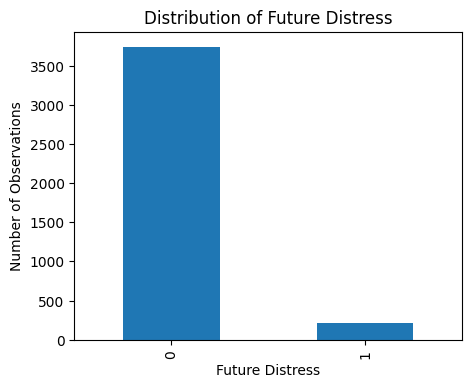

In [118]:
print(df_future["FutureDistress"].value_counts())

print()

print(
    (df_future["FutureDistress"].value_counts(normalize=True) * 100).round(2)
)

import matplotlib.pyplot as plt

df_future["FutureDistress"].value_counts().plot(
    kind="bar",
    figsize=(5,4)
)

plt.title("Distribution of Future Distress")
plt.xlabel("Future Distress")
plt.ylabel("Number of Observations")
plt.show()

In [119]:
# Sector Analysis

In [120]:
sector_counts = df_future["Sector"].value_counts()

sector_counts

,count
Sector,
Industrials,839
Basic Materials,603
Consumer Cyclical,575
Healthcare,455
Technology,367
Financial Services,275
Consumer Defensive,257
Utilities,195
Energy,147


In [121]:
sector_summary = (
    df_future.groupby("Sector")
    .agg(
        Companies=("Ticker", "nunique"),
        Observations=("Ticker", "count"),
        Distressed=("FutureDistress", "sum"),
        DistressRate=("FutureDistress", "mean")
    )
    .sort_values("DistressRate", ascending=False)
)

sector_summary

,Companies,Observations,Distressed,DistressRate
Sector,,,,
Communication Services,13,130,17,0.130769
Real Estate,11,114,12,0.105263
Financial Services,30,275,27,0.098182
Technology,39,367,27,0.073569
Industrials,83,839,52,0.061979
Consumer Cyclical,66,575,32,0.055652
Consumer Defensive,27,257,9,0.035019
Healthcare,50,455,14,0.030769
Basic Materials,62,603,18,0.029851


Engineered Financial Ratios Var.

In [122]:
# Healthy vs Distressed Firms

engineered_vars = [
    "ROA",
    "ROE",
    "OperatingMargin",
    "NetMargin",
    "DebtEquity",
    "EquityRatio",
    "CFOtoAssets",
    "FCFtoAssets",
    "AssetTurnover",
    "FixedAssetRatio",
    "CWIPRatio",
    "InvestmentRatio"
]

comparison = (
    df_future.groupby("FutureDistress")[engineered_vars]
    .agg(["mean", "median", "std"])
)

comparison

ROA                           ROE                      \
                    mean    median       std      mean    median       std   
FutureDistress                                                               
0               0.061910  0.042117  0.070652  0.117743  0.100808  0.348828   
1              -0.087138 -0.025584  0.334781 -0.356631 -0.014601  3.801343   

               OperatingMargin                      NetMargin  ...  \
                          mean    median        std      mean  ...   
FutureDistress                                                 ...   
0                     0.194341  0.172559   0.621035  0.155373  ...   
1                    -1.380695  0.003238  18.981866 -1.199426  ...   

               AssetTurnover FixedAssetRatio                     CWIPRatio  \
                         std            mean    median       std      mean   
FutureDistress                                                               
0                   0.547032        0.346555  0.332681  0.205125  0.044555   
1                   0.803151        0.270483  0.185047  0.248144  0.032977   

                                   InvestmentRatio                      
                  median       std            mean    median       std  
FutureDistress                                                          
0               0.019040  0.067218        0.124233  0.044004  0.194066  
1               0.010273  0.061034        0.147405  0.058486  0.199577  

[2 rows x 36 columns]

In [123]:
from scipy.stats import mannwhitneyu
import pandas as pd


results = []

for col in engineered_vars:
    healthy = df_future.loc[df_future["FutureDistress"] == 0, col]
    distressed = df_future.loc[df_future["FutureDistress"] == 1, col]

    stat, p = mannwhitneyu(healthy, distressed, alternative="two-sided")

    results.append({
        "Variable": col,
        "HealthyMedian": healthy.median(),
        "DistressedMedian": distressed.median(),
        "PValue": p
    })

results = pd.DataFrame(results).sort_values("PValue")

results

,Variable,HealthyMedian,DistressedMedian,PValue
0,ROA,0.042117,-0.025584,9.854472e-82
3,NetMargin,0.090412,-0.086378,1.305779e-62
6,CFOtoAssets,0.099738,-0.012925,2.779900e-52
2,OperatingMargin,0.172559,0.003238,5.637847e-39
7,FCFtoAssets,0.048076,-0.035463,8.921696e-37
5,EquityRatio,0.512856,0.232137,1.743149e-33
1,ROE,0.100808,-0.014601,5.785733e-28
8,AssetTurnover,0.542152,0.273443,2.509927e-13
9,FixedAssetRatio,0.332681,0.185047,1.032240e-09
10,CWIPRatio,0.019040,0.010273,1.815548e-06


Observations

- Profitability ratios, including ROA, Operating Margin and Net Margin, showed highly significant differences between healthy and distressed firms, indicating that distressed companies generally exhibit weaker profitability.
- Cash flow ratios (CFO-to-Assets and FCF-to-Assets) also demonstrated strong discriminatory power, suggesting that distressed firms generate substantially lower operating and free cash flows relative to their asset base.
- Capital structure indicators, particularly Equity Ratio, differed significantly between the two groups, reflecting the weaker financial position of distressed firms.
- Asset efficiency and investment-related ratios, such as Asset Turnover, Fixed Asset Ratio and CWIP Ratio, showed statistically significant differences, although their discriminatory power was relatively weaker than profitability and cash flow measures.
- Investment Ratio and Debt-to-Equity Ratio did not exhibit statistically significant differences between healthy and distressed firms, indicating limited standalone predictive value within this dataset.

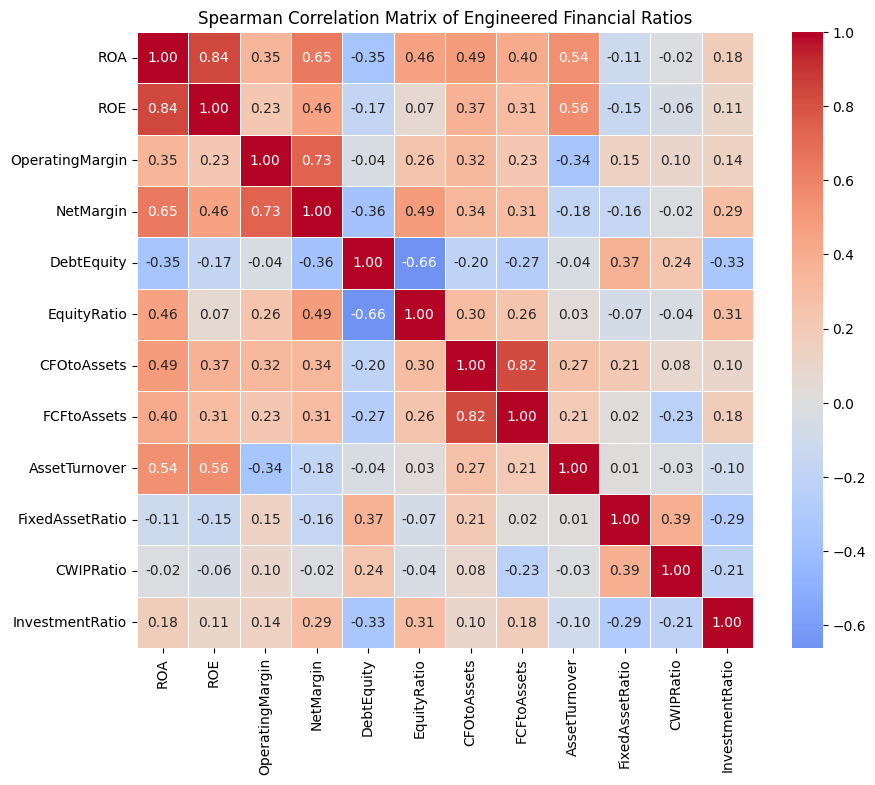

In [124]:
# Correlation Analysis

import matplotlib.pyplot as plt
import seaborn as sns

engineered_vars = [
    "ROA",
    "ROE",
    "OperatingMargin",
    "NetMargin",
    "DebtEquity",
    "EquityRatio",
    "CFOtoAssets",
    "FCFtoAssets",
    "AssetTurnover",
    "FixedAssetRatio",
    "CWIPRatio",
    "InvestmentRatio"
]

corr = df_future[engineered_vars].corr(method="spearman")

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Spearman Correlation Matrix of Engineered Financial Ratios")

plt.show()

In [125]:
# VIF

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_features = [
    "ROA",
    "ROE",
    "OperatingMargin",
    "NetMargin",
    "DebtEquity",
    "EquityRatio",
    "CFOtoAssets",
    "FCFtoAssets",
    "AssetTurnover",
    "FixedAssetRatio",
    "CWIPRatio",
    "InvestmentRatio"
]

X = df_future[vif_features].copy()

vif = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
})

vif.sort_values("VIF", ascending=False)

,Variable,VIF
7,FCFtoAssets,9.667323
6,CFOtoAssets,9.107448
3,NetMargin,5.932714
2,OperatingMargin,5.925196
5,EquityRatio,4.473470
9,FixedAssetRatio,2.907978
8,AssetTurnover,1.997386
0,ROA,1.948770
10,CWIPRatio,1.605267
11,InvestmentRatio,1.563054


FCFtoAssets 9.66 & CFOtoAssets 9.10  -- > FCFtoAssets ↔ CFOtoAssets = 0.82 (Corr)



Raw Financial Statement Variables

In [126]:
# Healthy vs Distressed

comparison_raw = (
    df_future
    .groupby("FutureDistress")[raw_vars]
    .agg(["mean","median","std"])
)

comparison_raw

Borrowings                                CFO         \
                        mean  median           std         mean median   
FutureDistress                                                           
0                8493.228098   781.5  28801.134112  2794.819979  596.0   
1               20578.408451  2589.0  51157.269156  -698.262911  -55.0   

                                    CWIP                      Depreciation  \
                        std         mean median           std         mean   
FutureDistress                                                               
0               9095.965041  2654.247062  113.5  15032.967020   660.775873   
1               7514.374352  1248.197183   83.0   4085.930888   794.391643   

                ...         Sales   TotalAssets                         \
                ...           std          mean  median            std   
FutureDistress  ...                                                      
0               ...  49499.688164  39071.217415  7215.5  211568.708112   
1               ...  16794.459308  35511.314554  8074.0   82685.823725   

               TotalLiabilities                               Equity          \
                           mean  median            std          mean  median   
FutureDistress                                                                 
0                  39071.217415  7215.5  211568.708112  12072.799794  3340.0   
1                  35511.314554  8074.0   82685.823725   3655.519296  1686.0   

                              
                         std  
FutureDistress                
0               37742.876291  
1               18344.275041  

[2 rows x 57 columns]

In [127]:
from scipy.stats import mannwhitneyu
import pandas as pd


results = []

for col in raw_vars:
    healthy = df_future.loc[df_future["FutureDistress"] == 0, col]
    distressed = df_future.loc[df_future["FutureDistress"] == 1, col]

    stat, p = mannwhitneyu(healthy, distressed, alternative="two-sided")

    results.append({
        "Variable": col,
        "HealthyMedian": healthy.median(),
        "DistressedMedian": distressed.median(),
        "PValue": p
    })

results = pd.DataFrame(results).sort_values("PValue")

results

,Variable,HealthyMedian,DistressedMedian,PValue
13,PBT,376.0,-108.5,1.837210e-57
9,NetProfit,282.5,-107.0,6.032330e-57
10,OperatingProfit,533.0,7.0,1.797720e-36
1,CFO,596.0,-55.0,3.021144e-36
5,FCF,244.0,-244.0,9.968613e-34
14,Reserves,3154.5,1323.0,6.370437e-18
18,Equity,3340.0,1686.0,5.159571e-15
0,Borrowings,781.5,2589.0,2.919159e-11
7,Interest,44.0,144.0,3.117516e-10
6,FixedAssets,1881.5,1228.0,5.371859e-04


 Observations

- Profitability and cash flow variables (PBT, Net Profit, Operating Profit, CFO and FCF) showed highly significant differences between healthy and distressed firms.
- Capital structure variables such as Borrowings, Interest Expense, Equity and Reserves also differed significantly across the two groups.
- Firm size variables, including Total Assets and Total Liabilities, did not exhibit statistically significant differences, suggesting that company size alone is not a strong indicator of future financial distress.
- Investment-related variables showed limited discriminatory power in this dataset.

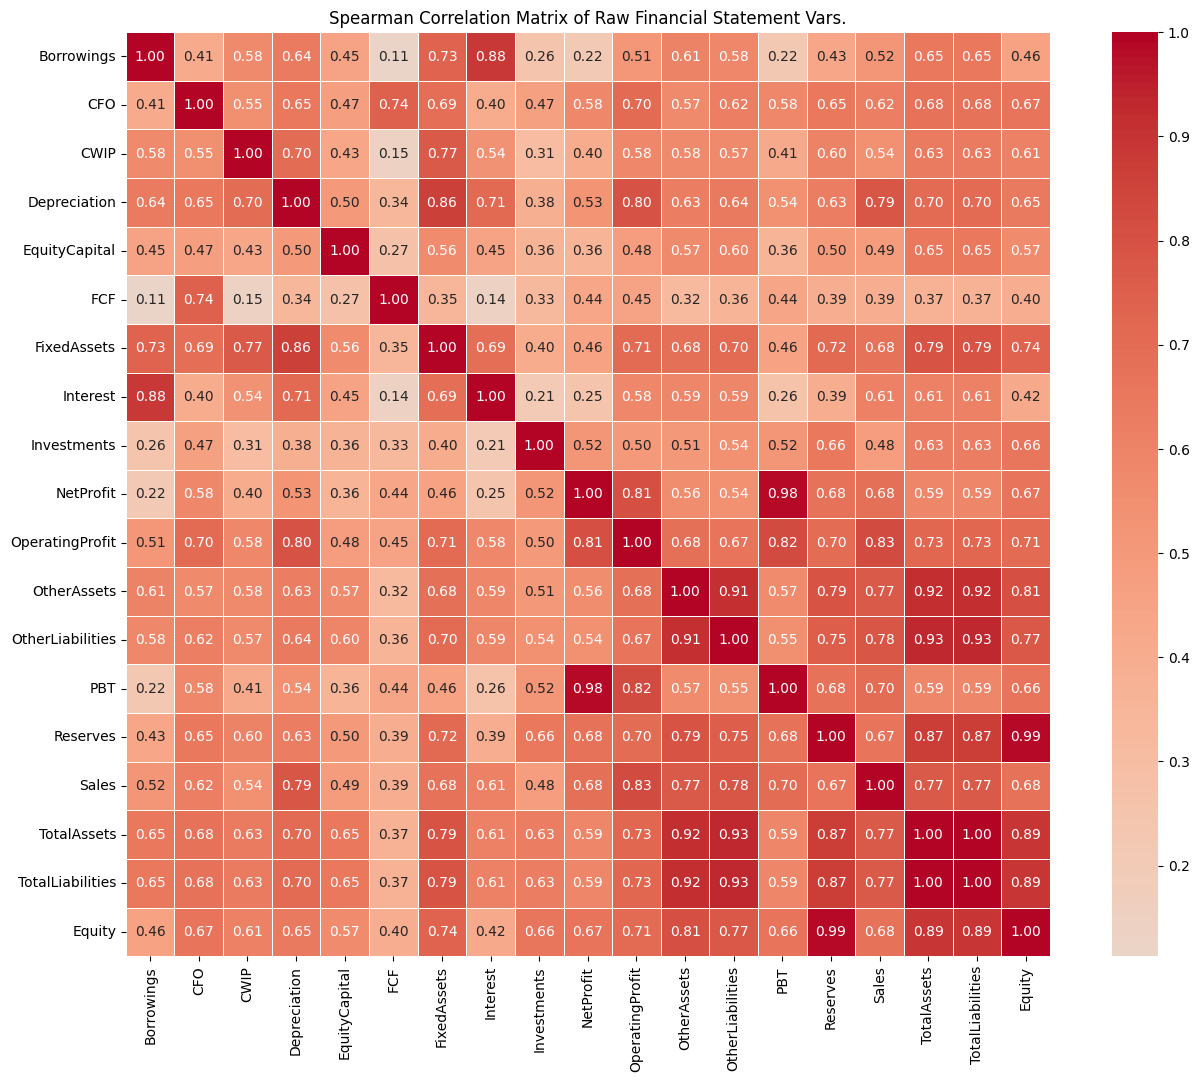

In [128]:
# Correlation Analysis

import matplotlib.pyplot as plt
import seaborn as sns


corr = df_future[raw_vars].corr(method="spearman")

plt.figure(figsize=(16,12))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Spearman Correlation Matrix of Raw Financial Statement Vars.")

plt.show()

In [129]:
# VIF

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd


X = df_future[raw_vars].copy()

vif = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
})

vif.sort_values("VIF", ascending=False)

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Variable,VIF
18,Equity,inf
17,TotalLiabilities,inf
4,EquityCapital,inf
16,TotalAssets,inf
14,Reserves,inf
12,OtherLiabilities,6.489664e+10
8,Investments,3.936885e+10
6,FixedAssets,2.411547e+09
0,Borrowings,1.910315e+09
11,OtherAssets,1.639566e+09


 Observations

- The raw financial statement variables exhibited substantially higher multicollinearity than the engineered financial ratios.
- Several variables showed perfect or near-perfect correlations because they are linked through accounting identities (e.g., Total Assets, Total Liabilities and Equity).
- Consequently, several predictors produced infinite or extremely large VIF values, indicating severe multicollinearity.
- This behaviour is expected for raw accounting data and motivates the use of engineered financial ratios, which provide more independent and economically interpretable measures of financial health.

In [130]:
df_future.to_csv(
    "financial_distress_modelling.csv",
    index=False
)

# Conclusion

The dataset has been cleaned, validated, feature engineered, and explored through EDA. It is now ready for predictive modeling. The next notebook focuses on scaling, feature selection, preprocessing, model development, evaluation, and interpretation.

In [131]:
df = pd.read_csv("/content/financial_distress_modelling.csv")

In [132]:
df[df["Year"] < 2015][["Ticker", "Year"]].sort_values(["Ticker", "Year"])

,Ticker,Year
25,ABB,2011
26,ABB,2012
64,ACC,2014
228,AMBUJACEM,2014
490,BAYERCROP,2005
760,CEMPRO,2014
904,COLPAL,2006
905,COLPAL,2007
906,COLPAL,2008
907,COLPAL,2009
